In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import emcee

from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
from lmfit import Model

import jeans
from baryonFit import HernquistFit
from readData import *

# Import the rotation curves for the baryon component

In [2]:
path = os.getcwd() + '/data/Rotmod_LTG/'

In [3]:
def get_data(filename):
    with open(filename) as f:
        lines = f.readlines()

    distance = float(lines[0].lstrip("# Distance = ").strip().split()[0])
    colnames = lines[1].lstrip("# ").split()
    units = lines[2].lstrip("# ").split()

    df = pd.read_csv(
        filename,
        comment="#",
        sep=r"\s+",
        names=colnames,
        skiprows=2    # skip the two # header lines
    )
    
    # stack colnames and units to turn into a new df
    units_df = pd.DataFrame([units], columns=colnames)
    
    return df, units_df, distance

In [42]:
filename = path + 'F568-3_rotmod.dat'

df, units, dist = get_data(filename)

df

,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul
0,0.64,12.4,8.60,1.18,13.56,0.0,67.54,0.0
1,1.18,21.9,6.20,1.55,21.17,0.0,56.11,0.0
2,1.80,32.3,1.88,1.60,27.72,0.0,46.30,0.0
3,2.03,37.9,6.20,1.54,29.76,0.0,44.10,0.0
4,2.78,53.1,9.50,1.46,36.40,0.0,37.67,0.0
5,3.00,62.4,11.00,1.62,38.08,0.0,35.56,0.0
6,3.64,68.0,6.20,2.96,42.40,0.0,30.26,0.0
7,4.19,78.0,7.98,5.28,45.43,0.0,25.29,0.0
8,4.60,82.3,6.20,6.86,46.43,0.0,21.07,0.0
9,5.14,85.7,6.30,8.92,47.19,0.0,19.58,0.0


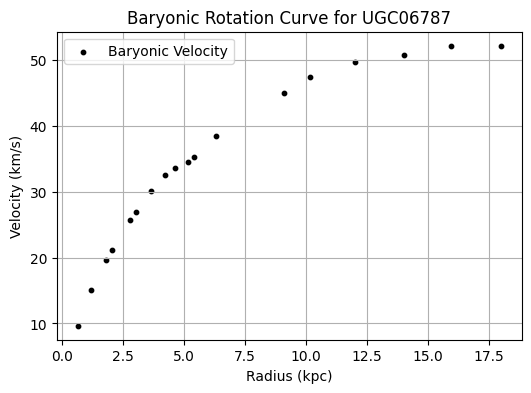

In [43]:
plt.figure(figsize=(6,4))

Vbaryon = np.sqrt(0.5*df['Vdisk']**2 + 0.7*df['Vbul']**2 + df['Vgas']**2)

plt.scatter(df['Rad'], Vbaryon, label='Baryonic Velocity', color='k', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Baryonic Rotation Curve for UGC06787')
plt.legend()
plt.grid()
plt.show()

# Gravitational potential 

The equation relating the rotation curve to the spherical gravitational potential is:

$$ 
V_c^2(r) = r \frac{d\Phi_B}{dr} = \frac{GM(<r)}{r} \quad ,
$$

where the rotation curve is defined component-wise as, 

$$
V_B^2(r) = \Upsilon_{\rm disk} V_{\rm disk}^2(r) + \Upsilon_{\rm bulge} V_{\rm bulge}^2(r) + V_{\rm gas}^2(r) \quad .
$$

The key equation for the potential is then, 

$$
\frac{d\Phi_B(r)}{dr} = \frac{V_B^2(r)}{r} \rightarrow \Phi_B(r) = - \int_{r}^{\infty} dr' \frac{V_B^2(r)}{r'} \quad . 
$$

Since we have data on a finite grid $\in [r_{\rm min}, r_{\rm max}]$ the integral becomes, 


$$
\Phi_B(r) = - \int_{r}^{r_{\rm max}} dr' \frac{V_B^2(r)}{r'} \quad ,
$$

where we are free to set $\Phi_B(r_{\rm max})=0$ since the Jeans model only depends on $\nabla\Phi_B$, i.e. the difference in potential. 

To do this efficiently we can precompute the integral over the range of data using the cumulative_trapezoid function in scipy.integrate. We can then enforce the conditions the $\Phi_B(r_{\rm max})=0$ and then interpolate the integral to get a function of phi that works for any radii. Mathematically the steps are, 

1. define $ f = V_B^2(r_i) / r_i $
2. numerically integrate $F = \int f dr_i$
3. Since $\int_r^{r_{\rm max}} f dr_i = F(r_{\rm max}) - F(r)$
4. Then $ \Phi_b(r) = - [F(r_{\rm max}) - F(r)] = F(r) - F(r_{\rm max}) $
5. Interpolate $\Phi_b$ on $r_i$ and return the function


In [57]:
def V_baryon(Upsilon_disk=0.5, Upsilon_bulge=0.7):
    V_disk = df['Vdisk'] * np.sqrt(Upsilon_disk)
    V_bulge = df['Vbul'] * np.sqrt(Upsilon_bulge)
    V_gas = df['Vgas'].to_numpy()  # gas mass-to-light ratio is fixed at 1.0
    V_baryon = np.sqrt(V_disk**2 + V_bulge**2 + V_gas**2)
    return V_baryon

def spherical_potential_baryon(Upsilon_disk=1.0, Upsilon_bulge=1.0):
    ri = df['Rad'].values
    vi = V_baryon().values
    
    # integrand function 
    f = vi**2 / ri
    
    # precompute cumulative integral
    F = cumulative_trapezoid(f, ri, initial=0.0)
    
    # normalize potential to be zero at infinity
    F_max = F[-1]
    phi_vals = F - F_max
    
    # create interpolation function 
    phi_interp = interp1d(ri, phi_vals, kind='linear', bounds_error=True)
    
    # return function that computes potential at given r
    def phi_baryon(r):
        return phi_interp(r)
    
    return phi_baryon
    

In [58]:
Phi_b = spherical_potential_baryon()

Phi_b([1,2,3])

array([-3558.57750757, -3358.65164623, -3127.26796962])

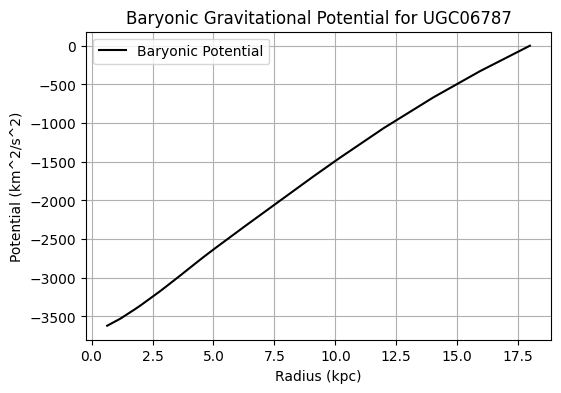

In [59]:
# test the potnetial for the range of radii in the data
radii = df['Rad'].values
phi_values = Phi_b(radii)

plt.figure(figsize=(6,4))
plt.plot(radii, phi_values, label='Baryonic Potential', color='k')
plt.xlabel('Radius (kpc)')
plt.ylabel('Potential (km^2/s^2)')
plt.title('Baryonic Gravitational Potential for UGC06787')
plt.legend()
plt.grid()
plt.show()

# Fitting a Hernquist profile

In [12]:
def rho_hernquist(r, M_b=10e10, a=1):
    """
    Takes:
    r : radius (kpc)
    M_b : total baryonic mass (solar masses)
    a : scale radius (kpc)
    Returns:
    rho : density at radius r (solar masses per cubic kpc)
    """
    return (M_b / (2 * np.pi * a**3)) / ((r / a) * (1 + r / a)**3)

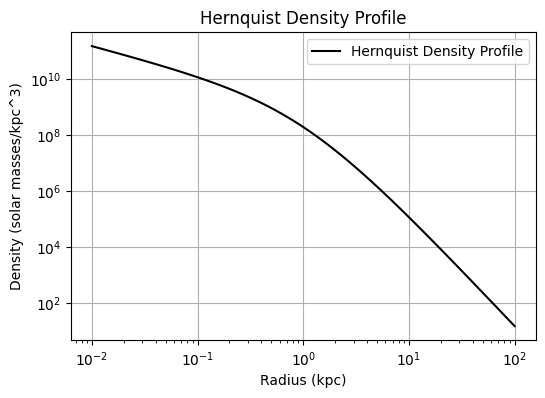

In [13]:
r = np.logspace(-2, 2, 100)  # radii from 0.01 to 100 kpc
rho = rho_hernquist(r, M_b=1e10, a=1)
plt.figure(figsize=(6,4))
plt.loglog(r, rho, label='Hernquist Density Profile', color='k')
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (solar masses/kpc^3)')
plt.title('Hernquist Density Profile')
plt.legend()
plt.grid()
plt.show()

## Fitting the baryon rotation curve

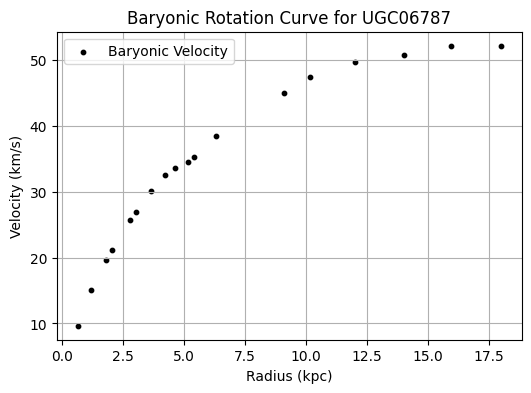

In [22]:
plt.figure(figsize=(6,4))

Vbaryon = np.sqrt(0.5*df['Vdisk']**2 + 0.7*df['Vbul']**2 + df['Vgas']**2)

plt.scatter(df['Rad'], Vbaryon, label='Baryonic Velocity', color='k', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Baryonic Rotation Curve for UGC06787')
plt.legend()
plt.grid()
plt.show()

In [28]:
def hernquist_model(r, M_b=1e10, a=1):
    """
    Circular velocity squared for Hernquist profile.
    Takes:
    r : radius (kpc)
    M_b : total baryonic mass (solar masses)
    a : scale radius (kpc)
    Returns:
    Vc : circular velocity at radius r (km/s)
    """
    G = 4.30091e-6  # gravitational constant in (kpc * (km/s)^2) / solar mass
    vc = np.sqrt(G * M_b * r) / (r + a)
    return vc

In [29]:
# try to fit the Hernquist model to the baryonic rotation curve data

V_baryon = np.sqrt(0.5*df['Vdisk']**2 + 0.7*df['Vbul']**2 + df['Vgas']**2)

# curve fitting
popt, pcov = curve_fit(hernquist_model, df['Rad'], V_baryon, p0=[1e10, 1])
M_b_fit, a_fit = popt
print(f"Fitted M_b: {M_b_fit:.2e} solar masses, a: {a_fit:.2f} kpc")

Fitted M_b: 2.76e+11 solar masses, a: 66.53 kpc


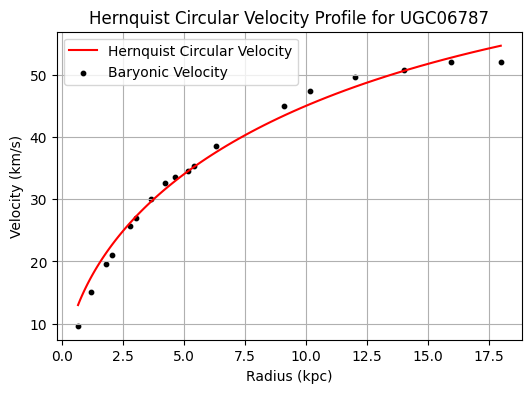

In [30]:
rvals = np.geomspace(df['Rad'].min(), df['Rad'].max(), 100)

vc_hern = [hernquist_model(r, M_b=M_b_fit, a=a_fit) for r in rvals]

plt.figure(figsize=(6,4))
plt.plot(rvals, vc_hern, label='Hernquist Circular Velocity', color='r')
plt.scatter(df['Rad'], V_baryon, label='Baryonic Velocity', color='k', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Hernquist Circular Velocity Profile for UGC06787')
plt.legend()
plt.grid()
plt.show()

In [70]:
def phi_hernquist(M_b=1e10, a=1):
    G = 4.30091e-6  # gravitational constant in (kpc * (km/s)^2) / solar mass
    
    def phi_func(r, th):
        return -G * M_b / (r + a)
    return phi_func

In [72]:
phi_b = phi_hernquist()

print(phi_b(10,np.pi))

-3909.918181818182


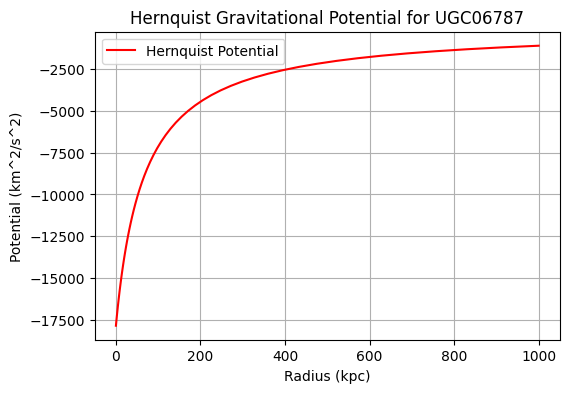

In [73]:
# plot the potential 
radii = np.logspace(-1, 3, 100)
phi_hern = phi_hernquist(M_b=M_b_fit, a=a_fit)   

phi_vals = [phi_hern(r, 0) for r in radii]

plt.figure(figsize=(6,4))
plt.plot(radii, phi_vals, label='Hernquist Potential', color='r')
plt.xlabel('Radius (kpc)')
plt.ylabel('Potential (km^2/s^2)')
plt.title('Hernquist Gravitational Potential for UGC06787')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# def likelihood(r,Mb=1e10,a=1,v_obs):
#     v_model = hernquist_model(r, M_b=M_b, a=a)
    
#     chisq = 
#     return -0.5 

# Fitting with the Jeans model 

In [81]:
M200 = 2e11 # solar masses
c = 10 # concentration parameter
r1 = 10 # kpc

phi_b = phi_hernquist(M_b=M_b_fit, a=a_fit) # function in r, theta

profile = jeans.squashed(r1, M200, c, Phi_b=phi_b)

if profile:
    print("Jeans profile computed successfully.")

Jeans profile computed successfully.


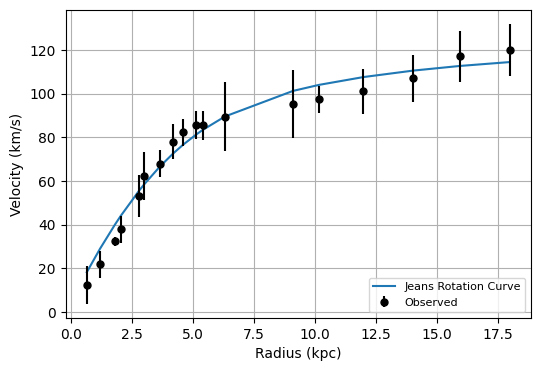

In [85]:
radii = df['Rad'].values
vc_jeans = profile.V(radii, Lmax=0)

plt.figure(figsize=(6,4))
plt.plot(radii, vc_jeans, label='Jeans Rotation Curve', color='C0')
plt.errorbar(df['Rad'], df['Vobs'], yerr=df['errV'], fmt='o', label='Observed', color='black', markersize=5)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.legend(fontsize=8, loc='lower right')
plt.grid()
plt.show()

# Trying with lmfit 

In [119]:
from lmfit import Model

In [120]:
def hernquist_model(r, M_b=1e10, a=1):
    """
    Circular velocity squared for Hernquist profile.
    Takes:
    r : radius (kpc)
    M_b : total baryonic mass (solar masses)
    a : scale radius (kpc)
    Returns:
    Vc : circular velocity at radius r (km/s)
    """
    G = 4.30091e-6  # gravitational constant in (kpc * (km/s)^2) / solar mass
    vc = np.sqrt(G * M_b * r) / (r + a)
    return vc

In [121]:
V_b_obs = np.sqrt(0.5*df['Vdisk']**2 + 0.7*df['Vbul']**2 + df['Vgas']**2)

In [122]:
V_model = Model(hernquist_model)
print(f'parameter names: {V_model.param_names}')
print(f'independent variables: {V_model.independent_vars}')
# params = V_model.make_params()
params = V_model.make_params(M_b=1e10, a=1)

r_eval = df['Rad'].values
y_eval = V_model.eval(params, r=r_eval)

result = V_model.fit(y, params, r=r_eval)

parameter names: ['M_b', 'a']
independent variables: ['r']


In [123]:
result.params['M_b'].value

276416994536.3144

In [126]:
result.chisqr

np.float64(41.5299320674311)

In [127]:
pcov

array([[6.73798120e+21, 9.22733266e+11],
       [9.22733266e+11, 1.26979467e+02]])

# Testing Baryon Class

In [2]:
galaxyID = "NGC1003"
gamma = 0.5
baryon_fitter = HernquistFit(galaxyID, gamma_star=0.5, gamma_bulge=0.7, method="lmfit")

Fitting with lmfit took 0.0100 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.22e+10 solar masses
  a   = 4.40 kpc
  chi-squared = 264.3338


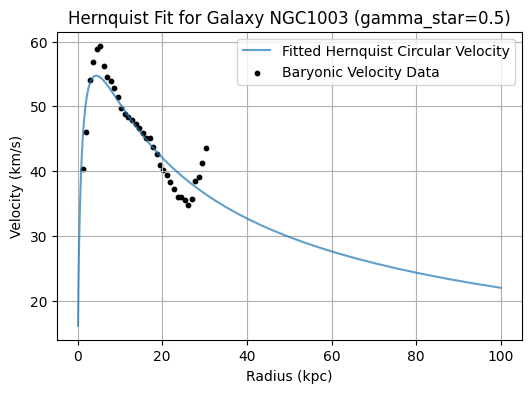

In [3]:
r_vals = np.geomspace(0.1, 100, 100)
vc_vals = baryon_fitter.vc(r_vals)

plt.figure(figsize=(6,4))
plt.plot(r_vals, vc_vals, label='Fitted Hernquist Circular Velocity', color='C0', alpha=0.7)
plt.scatter(baryon_fitter.r_vals, baryon_fitter.vc_baryons, label='Baryonic Velocity Data', color='k', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Hernquist Fit for Galaxy {galaxyID} (gamma_star={gamma})')
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

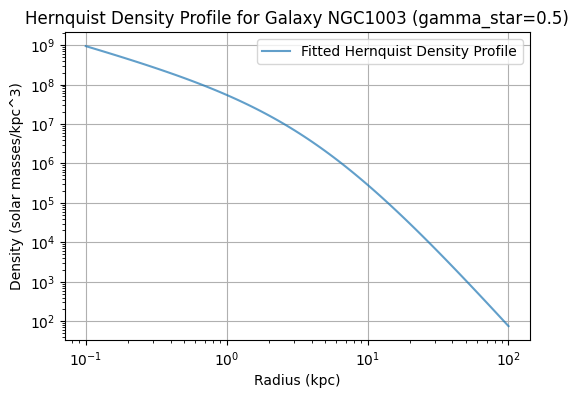

In [7]:
# density 

rho = baryon_fitter.density(r_vals)

plt.figure(figsize=(6,4))
plt.loglog(r_vals, rho, label='Fitted Hernquist Density Profile', color='C0', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (solar masses/kpc^3)')
plt.title(f'Hernquist Density Profile for Galaxy {galaxyID} (gamma_star={gamma})')
plt.legend()
plt.grid()
plt.show()


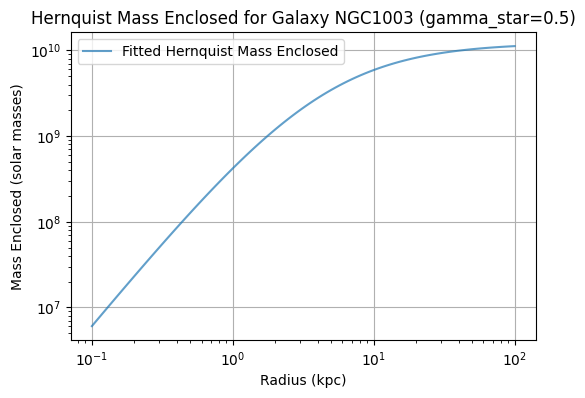

In [8]:
mass_enclosed = baryon_fitter.mass_enclosed(r_vals)

plt.figure(figsize=(6,4))
plt.loglog(r_vals, mass_enclosed, label='Fitted Hernquist Mass Enclosed', color='C0', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Mass Enclosed (solar masses)')
plt.title(f'Hernquist Mass Enclosed for Galaxy {galaxyID} (gamma_star={gamma})')
plt.legend()
plt.grid()
plt.show()

# Reading in the M-L data

In [2]:
from readData import *

In [4]:
galaxy = "CamB"
df, units = get_ML_data(galaxy)

df

,Model,Ydisk,e_Ydisk,Ybul,e_Ybul,D,e_D,inc,e_inc,V200,...,e_C200,rs,e_rs,log_rhos,e_log_rhos,log_M200,e_log_M200,alpha,e_alpha,Chi
0,pISO-Flat,0.34,0.07,0.0,0.0,3.07,0.26,57.9,5.2,457.41,...,3.94,28.40,9.47,-2.29,0.57,13.48,0.37,0.00,0.00,2.99
1,Burkert-Flat,0.33,0.07,0.0,0.0,3.07,0.26,58.1,5.2,423.46,...,1.35,61.26,20.80,-2.27,0.60,13.38,0.40,0.00,0.00,3.01
2,NFW-Flat,0.37,0.08,0.0,0.0,3.18,0.26,59.2,5.2,38.00,...,0.72,51.67,40.93,-4.29,1.19,10.24,0.44,0.00,0.00,8.61
3,NFW-LCDM,0.35,0.08,0.0,0.0,2.75,0.28,45.2,5.1,37.53,...,0.71,13.41,2.62,-3.15,0.27,10.23,0.08,0.00,0.00,7.92
4,Einasto-Flat,0.34,0.07,0.0,0.0,3.07,0.26,58.0,5.2,479.47,...,1.00,107.51,34.89,-2.74,0.56,13.55,0.37,1.92,0.42,7.92
5,Einasto-LCDM,0.36,0.07,0.0,0.0,2.90,0.27,53.0,5.4,39.40,...,0.74,10.06,1.52,-3.23,0.22,10.29,0.08,0.60,0.16,7.92
6,DC14-Flat,0.34,0.07,0.0,0.0,3.07,0.26,58.6,5.3,32.13,...,2.54,3.67,1.28,-2.45,0.50,10.02,0.36,0.00,0.00,4.14
7,DC14-LCDM,0.35,0.07,0.0,0.0,3.13,0.25,57.8,4.9,39.49,...,1.52,5.12,0.79,-2.55,0.17,10.29,0.08,0.00,0.00,4.41
8,coreNFW-Flat,0.35,0.07,0.0,0.0,3.00,0.27,57.0,5.5,12.48,...,5.82,1.44,1.45,-1.99,1.75,8.79,1.15,0.00,0.00,7.17
9,coreNFW-LCDM,0.34,0.08,0.0,0.0,2.69,0.29,42.2,5.0,36.77,...,1.57,7.95,2.04,-2.65,0.35,10.20,0.08,0.00,0.00,4.94


In [5]:
units

,Model,Ydisk,e_Ydisk,Ybul,e_Ybul,D,e_D,inc,e_inc,V200,...,e_C200,rs,e_rs,log_rhos,e_log_rhos,log_M200,e_log_M200,alpha,e_alpha,Chi
0,,,,,,Mpc,Mpc,deg,deg,km/s,...,,kpc,kpc,Msun/pc^3,Msun/pc^3,Msun,Msun,,,


In [18]:
def Gamma(galaxy):
    df, _ = get_ML_data(galaxy)
    numerator = np.sum(df['Ydisk'] / df['e_Ydisk']**2)
    denominator = np.sum(1 / df['e_Ydisk']**2)
    gamma = np.divide(numerator, denominator)
    
    # uncertainty in gamma
    sigma_gamma_sq = 1 / denominator
    
    # add spread in Ydisk values since Gamma_i are correlated
    w = 1 / df['e_Ydisk']**2
    spread_sq = np.sum(w * (df['Ydisk'] - gamma)**2) / np.sum(w)
    sigma_eff = np.sqrt(sigma_gamma_sq + spread_sq)
    
    return gamma, sigma_eff

In [19]:
Gamma(galaxy)

(np.float64(0.3453665283540802), np.float64(0.02312327508384736))

# Likelihood for Jeans rotation curves

In [22]:
galaxyID = "F568-3"

gamma_fits = pd.read_csv(os.getcwd() + f"/data/fit_data/gamma_fits.csv")
gamma_s, gamma_b = gamma_fits[gamma_fits["GalaxyID"] == galaxyID][["Gamma_disk", "Gamma_bulge"]].values[0]

# b_fits = pd.read_csv(os.getcwd() + f"/data/fit_data/hernquist_fit_results_gamma.csv")
# baryon_fit = b_fits[b_fits["GalaxyID"] == galaxyID]
# M_b_fit = baryon_fit["M_b_fit"].values[0]
# a_fit = baryon_fit["a_fit"].values[0]

# print(f"M_b_fit: {M_b_fit}, a_fit: {a_fit}")

bf = HernquistFit(galaxyID, gamma_star=gamma_s, gamma_bulge=gamma_b, method="lmfit")
print(f"Fitted M_b: {bf.M_b_fit}, a: {bf.a_fit}")

M200 = 1e11 # solar masses
c = 10 # concentration parameter
r1 = 10 # kpc

phi_b = bf.phi() # function in r, theta

print(phi_b(10,0))

profile = jeans.squashed(r1, M200, c, Phi_b=phi_b)

if profile:
    print("Jeans profile computed successfully.")

Fitting with lmfit took 0.0109 seconds
Fitted parameters for galaxy F568-3 using lmfit:
  M_b = 2.89e+11 solar masses
  a   = 68.75 kpc
  chi-squared = 41.0210
Fitted M_b: 288858221763.985, a: 68.75185813603512
-15775.541605899796
Jeans profile computed successfully.


In [40]:
theta = [10,2e11,10.511025699937301] 

profile = model(theta)

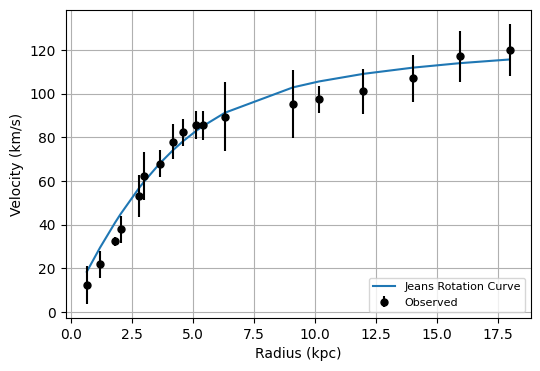

In [41]:
df, _, _ = get_rc_data(galaxyID)

radii = df['Rad'].values
vc_jeans = profile.V(radii, Lmax=0)

plt.figure(figsize=(6,4))
plt.plot(radii, vc_jeans, label='Jeans Rotation Curve', color='C0')
plt.errorbar(df['Rad'], df['Vobs'], yerr=df['errV'], fmt='o', label='Observed', color='black', markersize=5)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.legend(fontsize=8, loc='lower right')
plt.grid()
plt.show()

In [39]:
galaxyID = "F568-3"

phi_data = pd.read_csv(os.getcwd() + f"/data/fit_data/hernquist_fit_results_gamma.csv")
baryon_fit = phi_data[phi_data["GalaxyID"] == galaxyID]
M_b_fit = baryon_fit["M_b_fit"].values[0]
a_fit = baryon_fit["a_fit"].values[0]

data, _, _ = get_rc_data(galaxyID) 


def Phi_b(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func
    
def model(theta):
    r1, M200, c = theta
    phi_b = Phi_b(M_b_fit, a_fit) # function in r, theta

    # kwargs = {"AC_prescription": "Cautun"}
    profile = jeans.squashed(r1, M200, c, Phi_b=phi_b)
    
    if profile is None:
        print("Jeans profile computation failed.") 

    return profile

def likelihood(theta):
    profile = model(theta)
    
    r_vals = data['Rad'].values
    v_obs = data['Vobs'].values
    err_v = data['errV'].values
    
    v_model = profile.V(r_vals, Lmax=0)
    
    chisq = np.sum(((v_obs - v_model) / err_v)**2)
    return -0.5 * chisq, profile.cross_section()
    

In [30]:
theta = [10,1e11,10.511025699937301] # example parameters: [r1, M200, c]
likelihood(theta)

(np.float64(-17.70160291032179), np.float64(2.5341584672591684))

In [28]:
profile.cross_section()

np.float64(2.6118202991820123)

# emcee analysis

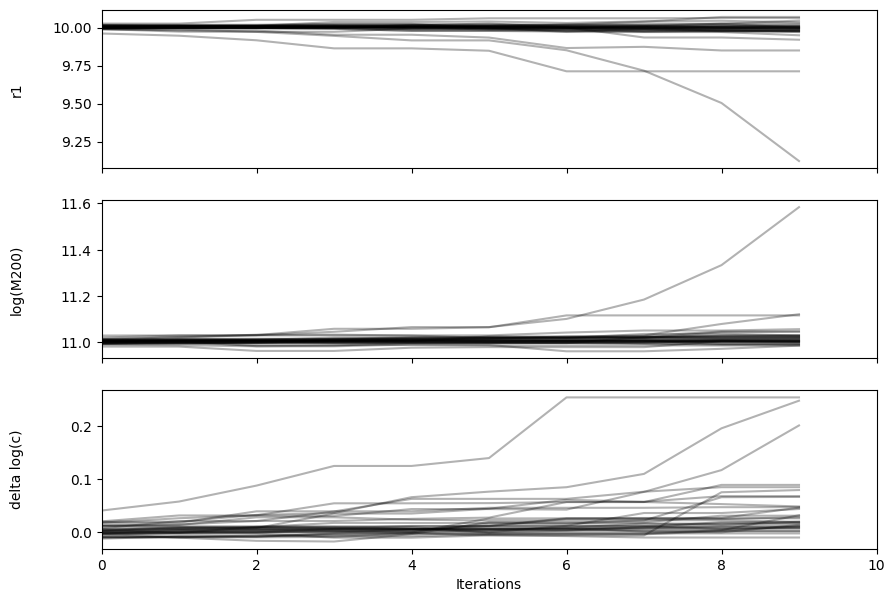

In [5]:
filename = os.getcwd() + '/data/MCMC_results/F571-8_sph_mcmc_nw_32_ni_10.h5'

reader = emcee.backends.HDFBackend(filename)

niter = reader.iteration

chain = reader.get_chain()

labels = ['r1', 'log(M200)', 'delta log(c)']
panels = chain.shape[2]

fig, axes = plt.subplots(panels, figsize=(10, 7), sharex=True)
for i in range(panels):
    ax = axes[i]
    ax.plot(chain[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, chain.shape[0])
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Iterations")

plt.show()

320


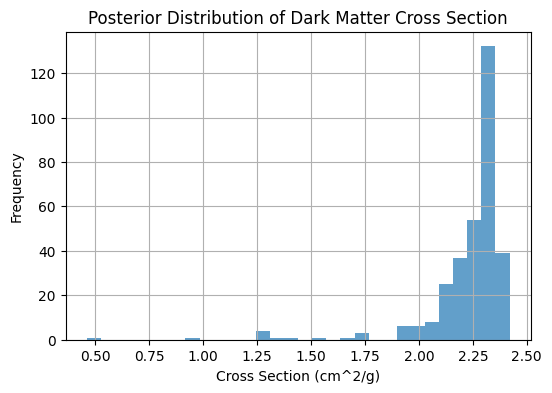

In [8]:
blobs = reader.get_blobs(flat=True)
cross_section = blobs['cross-section']
print(len(cross_section))
plt.figure(figsize=(6,4))
plt.hist(cross_section, bins=30, color='C0', alpha=0.7)
plt.xlabel('Cross Section (cm^2/g)')
plt.ylabel('Frequency')
plt.title('Posterior Distribution of Dark Matter Cross Section')
plt.grid()
plt.show()

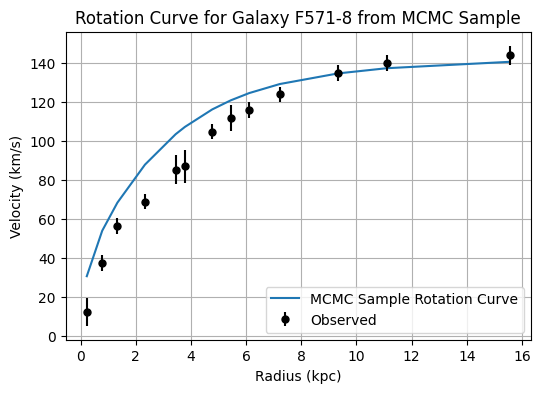

In [18]:
rcs = blobs['rotation-curve']
# print(rcs.shape)
galaxyID = "F571-8"
df, _, _ = get_rc_data(galaxyID)

test = rcs[289]
plt.figure(figsize=(6,4))
plt.plot(df['Rad'], test, label='MCMC Sample Rotation Curve', color='C0')
plt.errorbar(df['Rad'], df['Vobs'], yerr=df['errV'], fmt='o', label='Observed', color='black', markersize=5)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Rotation Curve for Galaxy {galaxyID} from MCMC Sample')
plt.legend()
plt.grid()
plt.show()

In [17]:
log_probs = reader.get_log_prob(flat=True)
best_idx = np.argmax(log_probs)
best_log_prob = log_probs[best_idx]
print(best_idx)

289


In [19]:
flatchain = reader.get_chain(flat=True)
best_params = flatchain[best_idx]
print(f"Best-fit parameters: r1={best_params[0]}, M200={10**best_params[1]}, dlogc={best_params[2]}")

Best-fit parameters: r1=9.122069346629889, M200=383700243862.5621, dlogc=0.20077993150962772


In [20]:
def transform(theta):
    r1, logM200, dlogc = theta
    M200 = 10**logM200
    c = c_MCR(M200) * (10**dlogc)

    return r1, M200, c

def c_MCR(M200):
    """
    Returns:
        c from the mass-concentration relations without error factor delta(log(c))
    """
    a, b = 0.905, -0.101
    h = 0.7
    c = 10 ** (a + b * np.log10(h * M200 / 1e12))

    return c

transform(best_params)

(np.float64(9.122069346629889),
 np.float64(383700243862.5621),
 np.float64(14.569405466092666))

In [21]:
def phi_Hern_sph(M_b=1e10, a=10):
    """
    Spherical Hernquist potential.
    Takes:
        M_b : total baryonic mass [solar masses]
        a : scale radius [kpc]
    Returns:
        phi_Hern_sph : function that takes radius r [kpc] and returns potential [km^2/s^2]
    """
    G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]

    def potential(r, th):  # theta is a dummy variable for compatibility
        return -G * M_b / (r + a)

    return potential

def model(theta, **kwargs):
    r1, M200, c = transform(theta)

    phi_b = phi_Hern_sph(M_b=M_b_fit, a=a_fit)

    profile = jeans.squashed(r1, M200, c, Phi_b=phi_b, **kwargs)

    return profile

In [24]:
GalaxyID = "F571-8"
baryon_fit_data = pd.read_csv(
    os.getcwd() + "/data/fit_data/hernquist_fit_results_gamma.csv"
)
baryon_data = baryon_fit_data[baryon_fit_data["GalaxyID"] == GalaxyID]
M_b_fit = baryon_data["M_b_fit"].values[0]  # solar masses
a_fit = baryon_data["a_fit"].values[0]  # kpc

profile = model(best_params)

In [26]:
data, _, _ = get_rc_data(GalaxyID)

In [32]:
g_data = pd.read_csv(os.getcwd() + "/data/fit_data/gamma_fits.csv")

gamma_s, gamma_b = g_data[g_data['GalaxyID']==GalaxyID][['Gamma_disk', 'Gamma_bulge']].values[0]

print(gamma_s, gamma_b)

0.2508488240436446 0.0


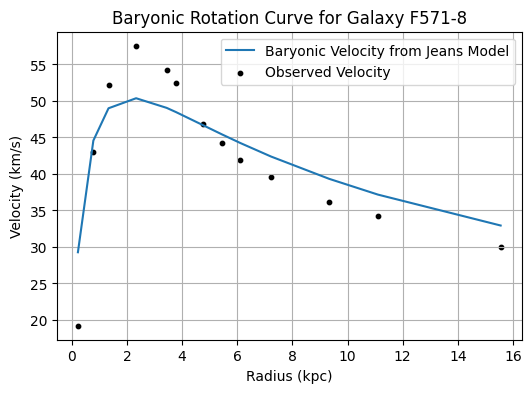

In [33]:
vc_b = profile.V_baryon(data['Rad'].values)
vc_b_data = np.sqrt(gamma_s * data['Vdisk']**2 + data['Vgas']**2)

plt.figure(figsize=(6,4))
plt.plot(data['Rad'], vc_b, label='Baryonic Velocity from Jeans Model', color='C0')
plt.scatter(data['Rad'], vc_b_data, label='Observed Velocity', color='black', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Baryonic Rotation Curve for Galaxy {GalaxyID}')
plt.legend()
plt.grid()
plt.show()

# Model for the Bulge

In [2]:
galaxyIDs = get_galaxy_ids()

In [3]:
bulge_list = []

for gal in galaxyIDs:
    df, _, _ = get_rc_data(gal)
    vbul = df.Vbul.values 
    
    if np.any(vbul > 0):
        bulge_list.append(gal)

print("Total number of galaxies:", len(galaxyIDs))
print("Number of galaxies with bulge component:", len(bulge_list))
print("Galaxies with bulge component:", bulge_list)

Total number of galaxies: 175
Number of galaxies with bulge component: 32
Galaxies with bulge component: ['NGC5005', 'NGC6195', 'UGC08699', 'NGC2841', 'NGC5985', 'UGC05253', 'UGC03546', 'NGC6946', 'UGC06614', 'NGC5033', 'UGC02885', 'UGC06973', 'UGC02487', 'NGC2683', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'NGC2955', 'UGC03580', 'UGC06786', 'NGC6674', 'UGC09133', 'UGC02953', 'NGC4138', 'IC4202', 'NGC4013', 'UGC03205', 'NGC7331', 'UGC02916', 'NGC4217', 'NGC4157']


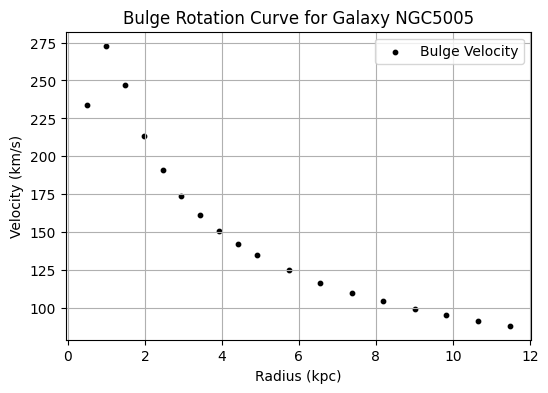

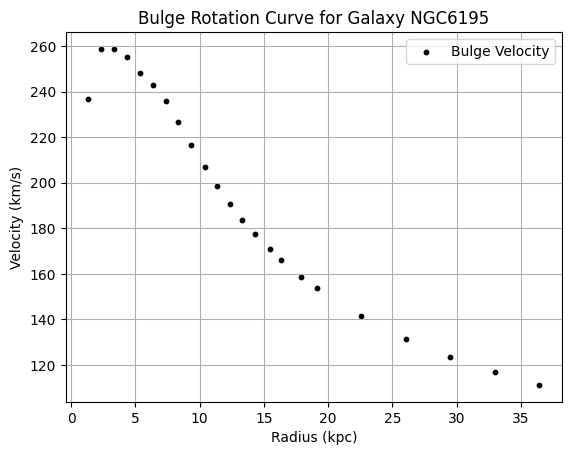

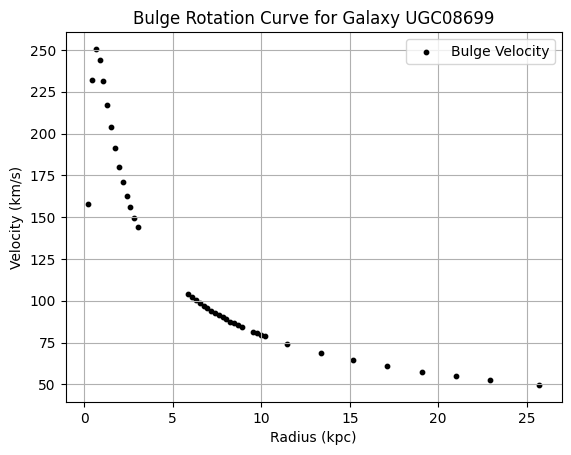

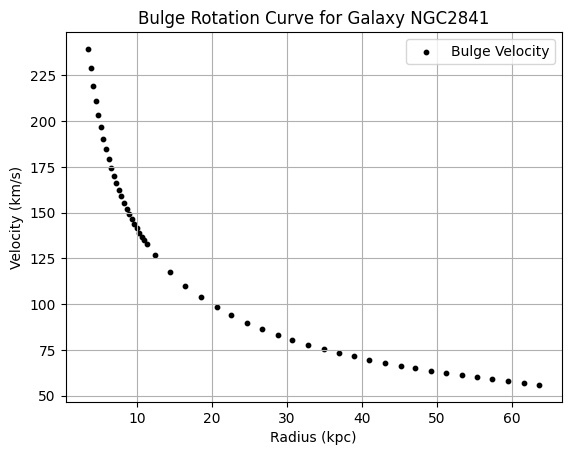

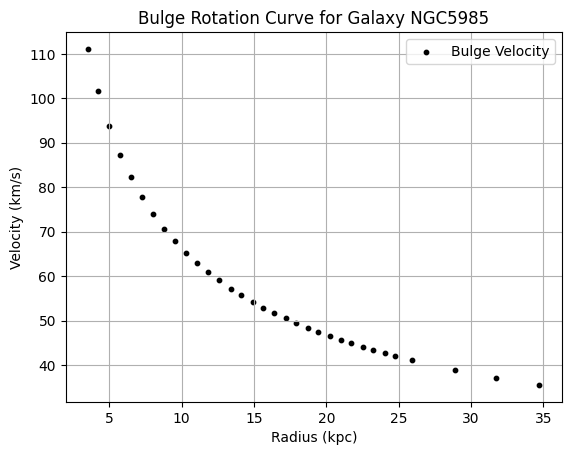

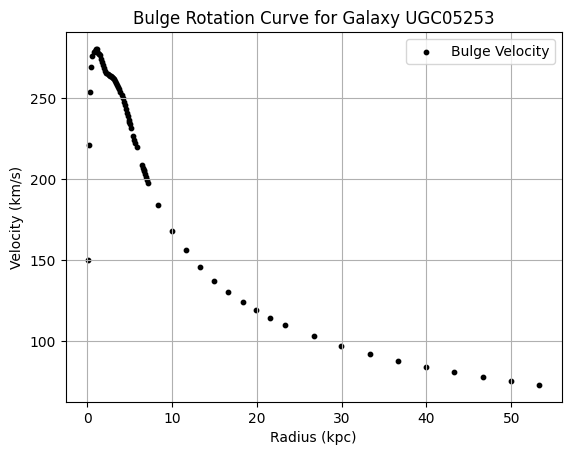

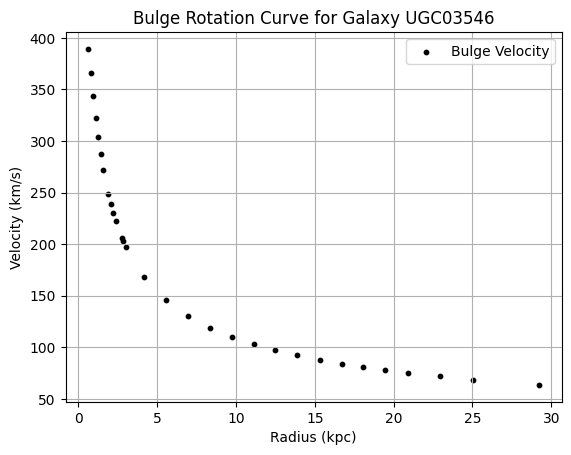

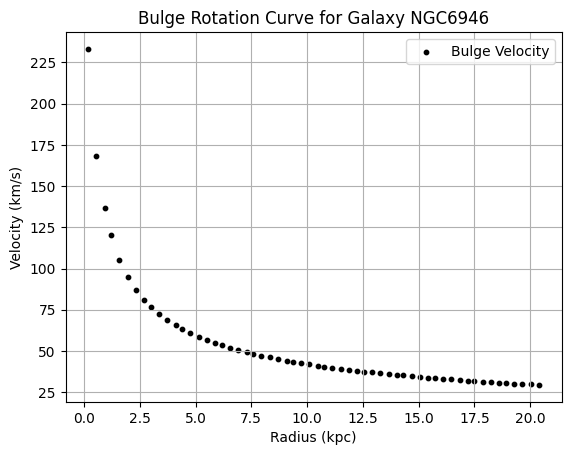

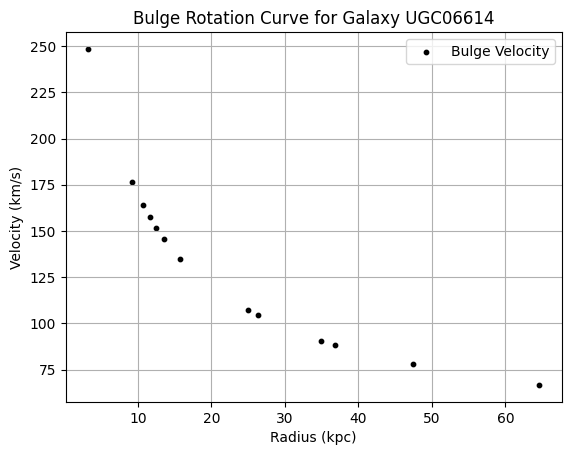

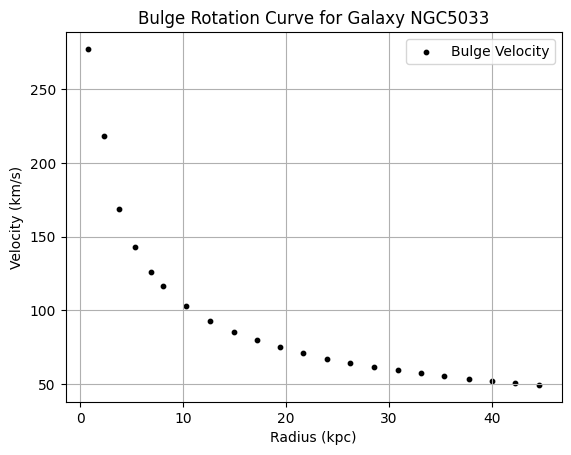

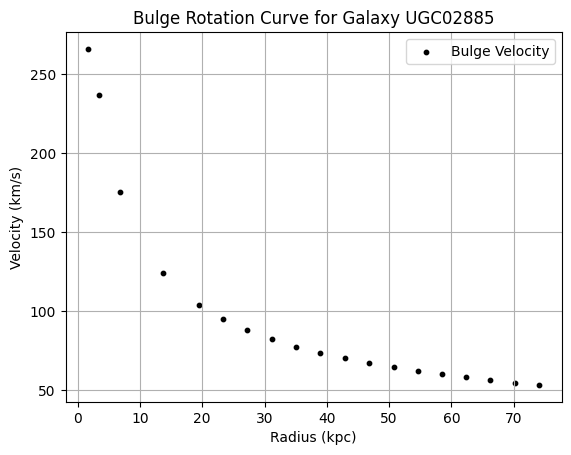

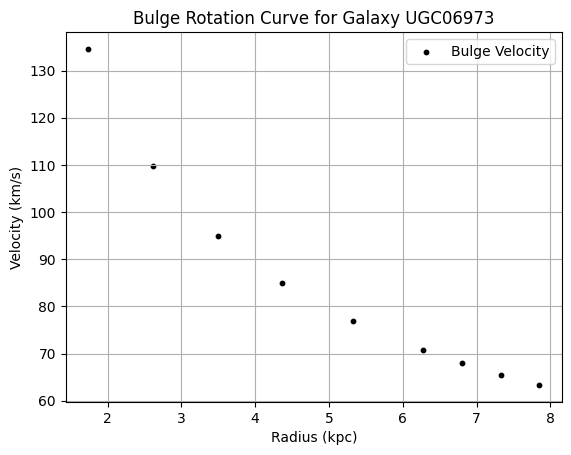

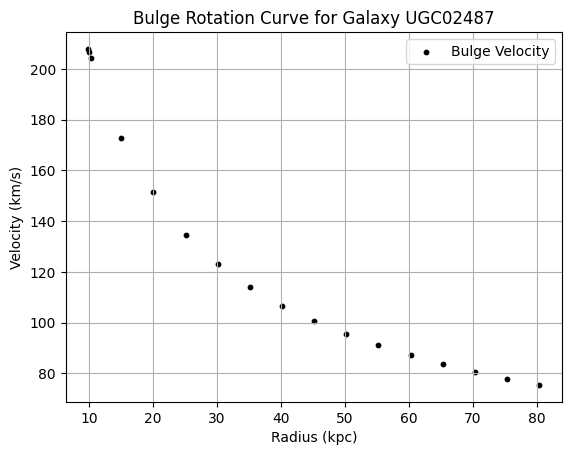

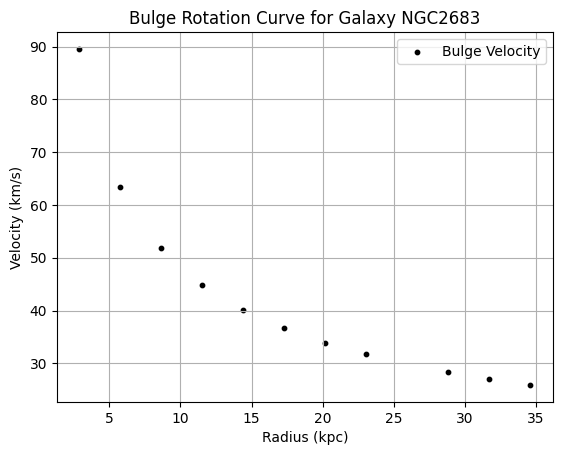

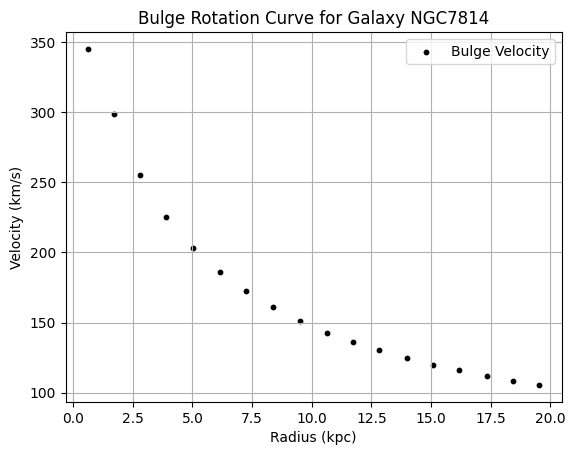

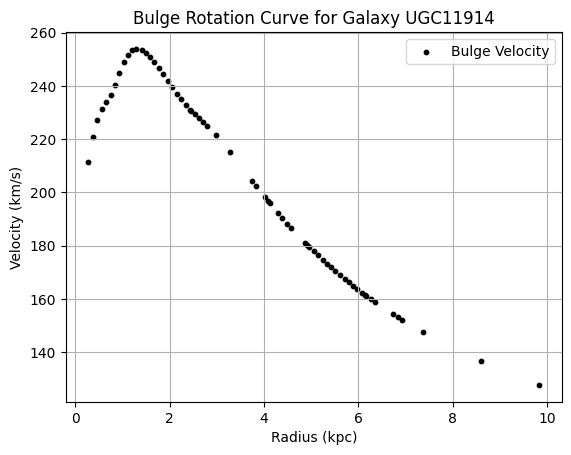

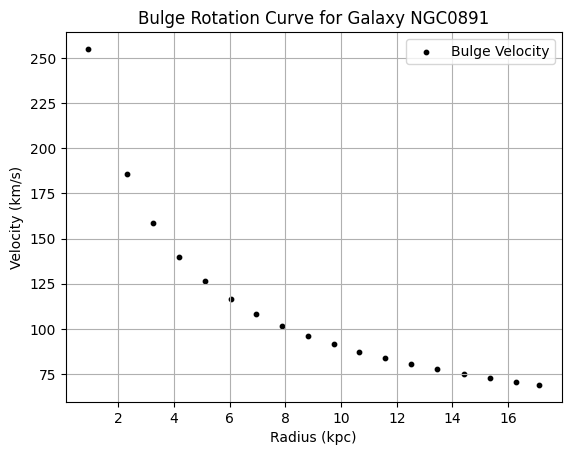

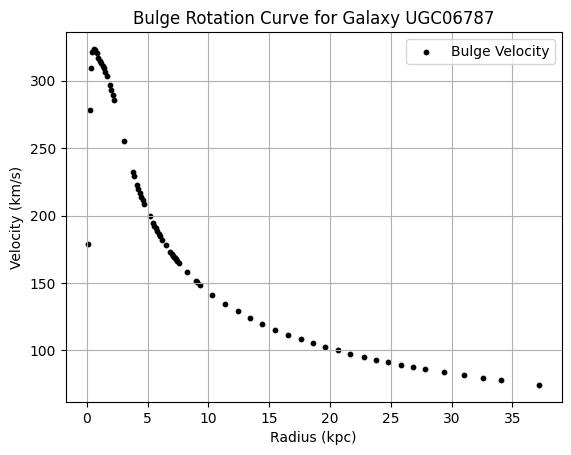

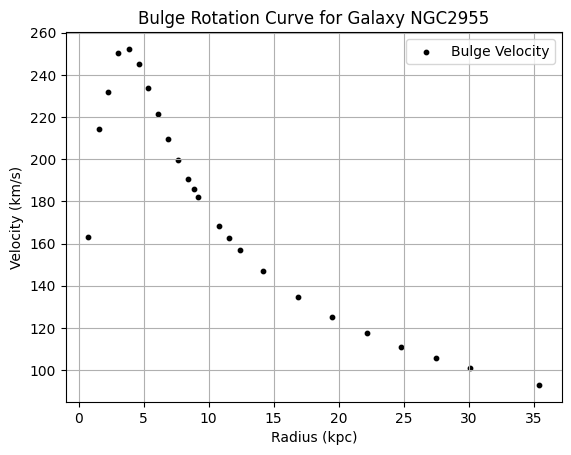

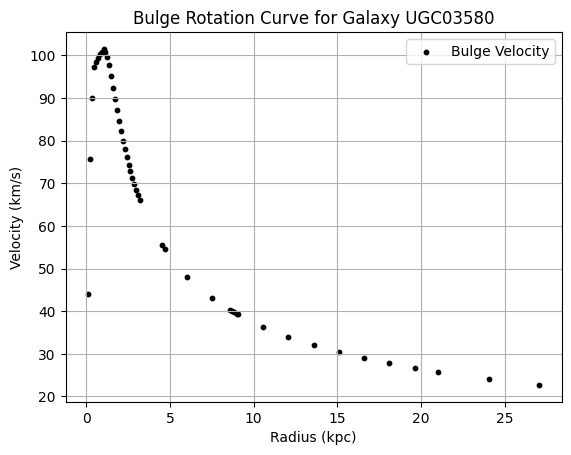

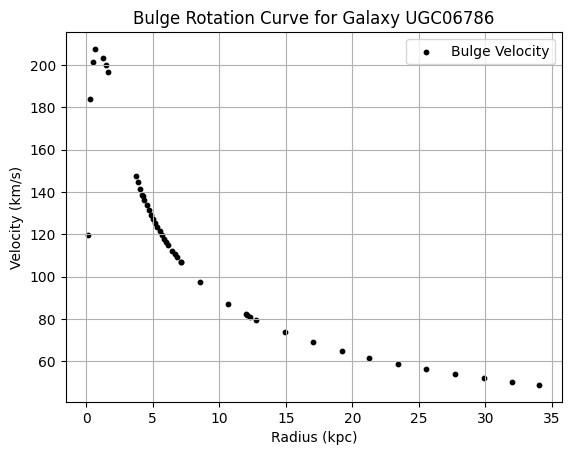

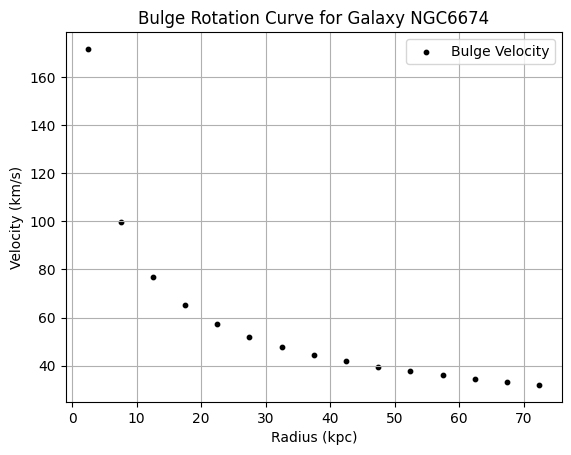

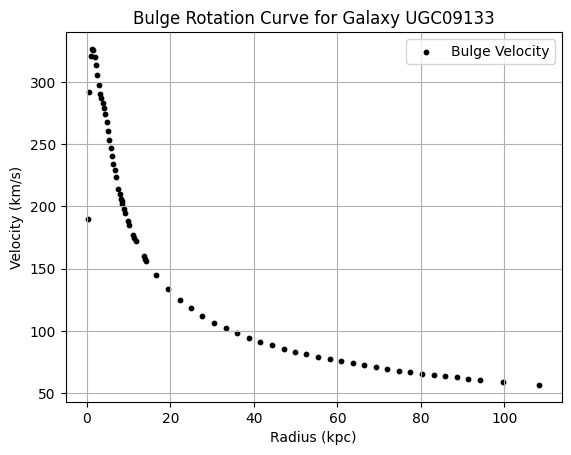

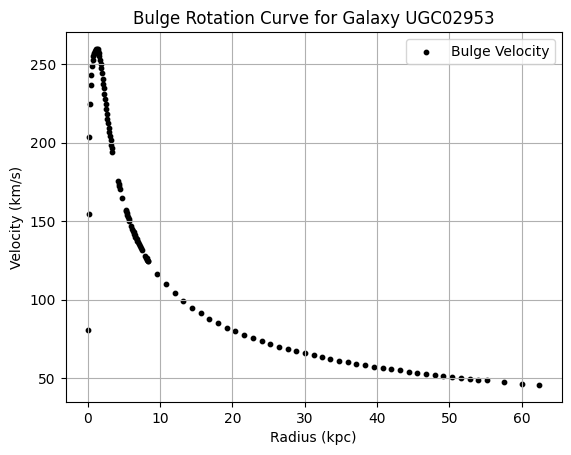

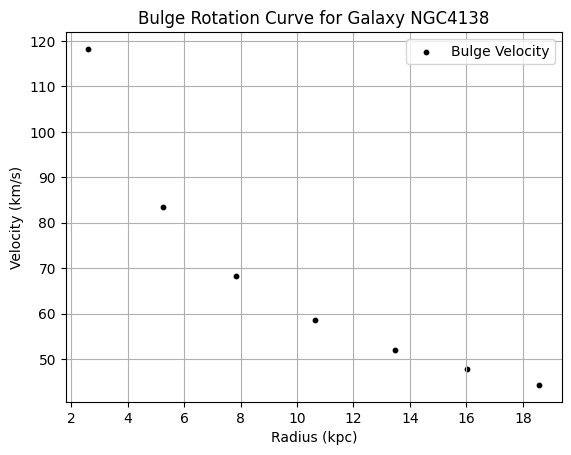

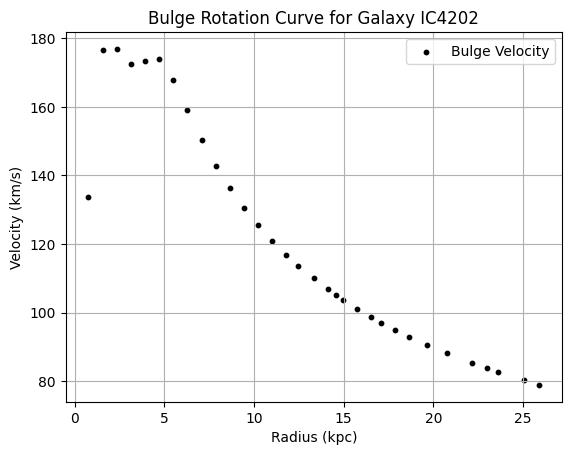

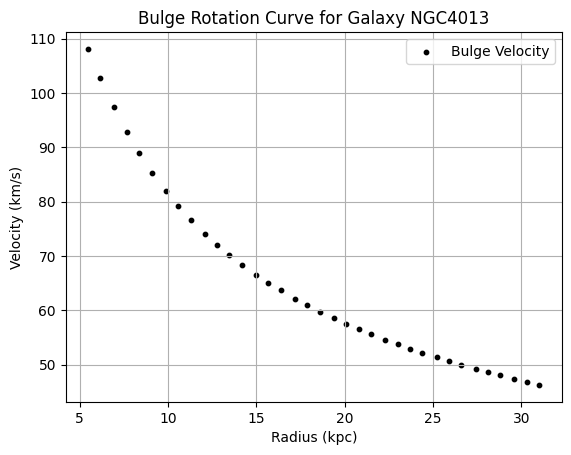

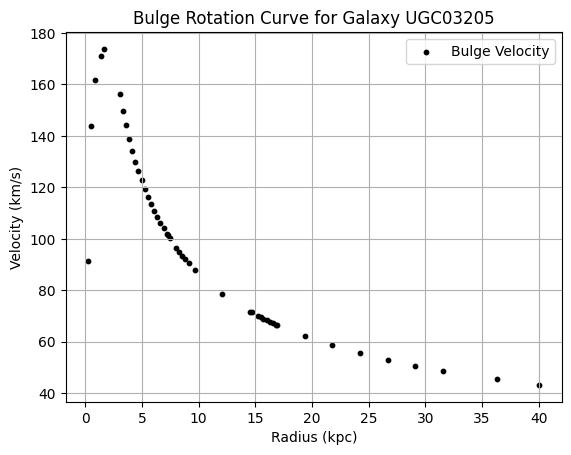

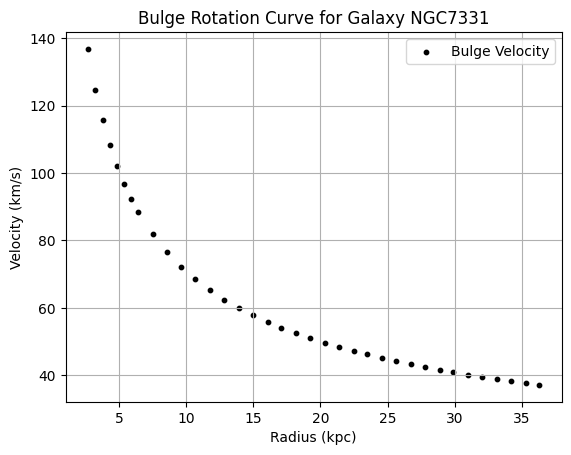

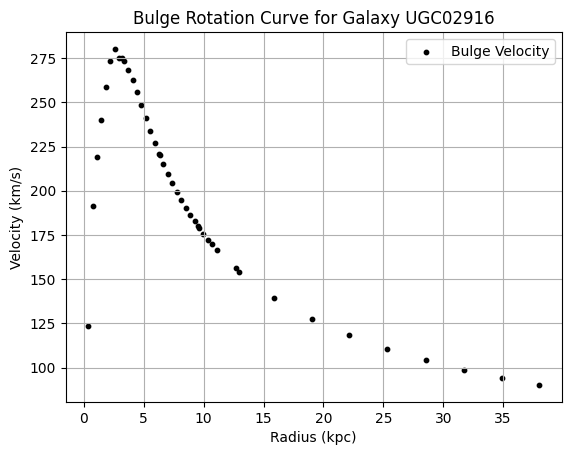

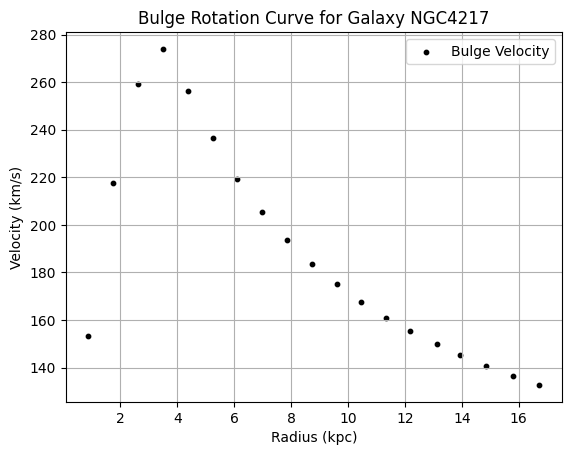

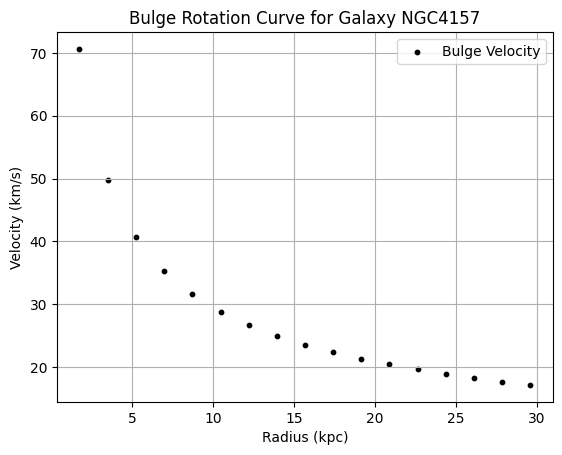

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(6,4))

for gal in bulge_list:
    df, _, _ = get_rc_data(gal)

    plt.scatter(df['Rad'], df['Vbul'], label='Bulge Velocity', color='k', s=10)
    # plt.scatter(df['Rad'], df['Vgas'], label='Gas Velocity', color='C0', s=10)
    plt.xlabel('Radius (kpc)')
    plt.ylabel('Velocity (km/s)')
    plt.title(f'Bulge Rotation Curve for Galaxy {gal}')
    plt.legend()
    plt.grid()
    plt.show()
    plt.clf()

In [4]:
# test baryon fit now 
gal = bulge_list[0]

gammad, _ = Gamma_disk(gal)
gammab, _ = Gamma_bulge(gal)

print(f"Gamma_disk: {gammad}, Gamma_bulge: {gammab}")

fitter = HernquistFit(gal, gamma_star=gammad, gamma_bulge=gammab, method="lmfit")


Gamma_disk: 0.5194002562586241, Gamma_bulge: 0.5637818345246758
Fitting with lmfit took 0.0145 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0100 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.50e+10 solar masses
  a   = 0.41 kpc
  chi-squared = 1970.0142


In [3]:
def hernquist_model(r, M_b=10, a=1):
    """
    Circular velocity squared for Hernquist profile.
    Takes:
        r : radius [kpc] (or array of radii)
        M_b : total baryonic mass [solar masses]
        a : scale radius [kpc]
    Returns:
        Vc : circular velocity at radius r [km/s]
    """
    G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]
    vc = np.sqrt(G * M_b * r) / (r + a)
    return vc

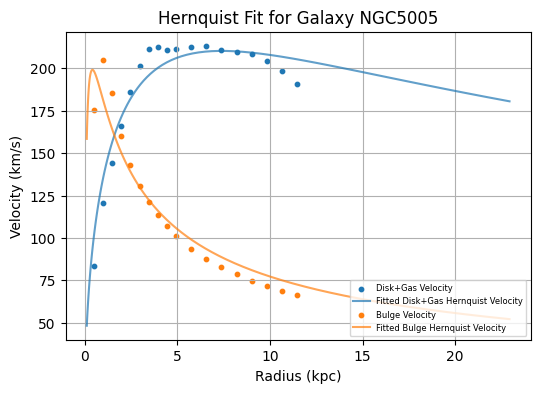

In [27]:
M_b_fit = fitter.M_b_fit
a_fit = fitter.a_fit
M_b_fit_b = fitter.M_b_fit_bulge
a_fit_b = fitter.a_fit_bulge

r_vals = fitter.r_vals

ri = np.geomspace(0.1, r_vals.max() * 2, 100)

vcds_fit = hernquist_model(ri, M_b=M_b_fit, a=a_fit)
vcb_fit = hernquist_model(ri, M_b=M_b_fit_b, a=a_fit_b)

vcdg = fitter.vc_disk_gas
vcb = fitter.vc_bulge

plt.figure(figsize=(6,4))

plt.scatter(r_vals, vcdg, label='Disk+Gas Velocity', color='C0', s=10)
plt.plot(ri, vcds_fit, label='Fitted Disk+Gas Hernquist Velocity', color='C0', alpha=0.7)
plt.scatter(r_vals, vcb, label='Bulge Velocity', color='C1', s=10)
plt.plot(ri, vcb_fit, label='Fitted Bulge Hernquist Velocity', color='C1', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Hernquist Fit for Galaxy {gal}')
plt.legend(fontsize=6, loc="lower right")
plt.grid()
plt.show()  

In [13]:
def phi(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func

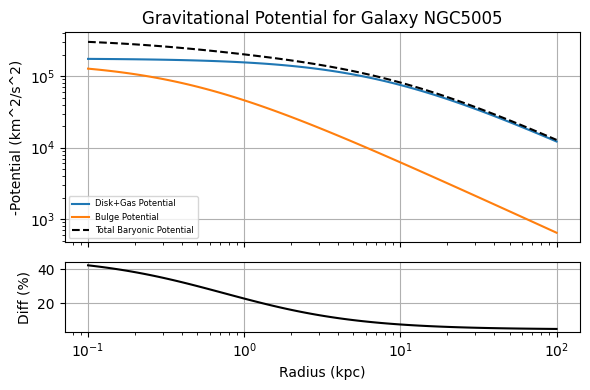

In [33]:
ri = np.geomspace(0.1, 100, 100)
phi_dg = np.abs(np.array([phi(M_b_fit, a_fit)(r, 0) for r in ri]))
phi_b  = np.abs(np.array([phi(M_b_fit_b, a_fit_b)(r, 0) for r in ri]))

phi_total = phi_dg + phi_b

percent_diff = 100 * ( np.abs((phi_total - phi_dg)) / np.abs(phi_total) )

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


axs[0].plot(ri, phi_dg, label='Disk+Gas Potential', color='C0')
axs[0].plot(ri, phi_b, label='Bulge Potential', color='C1')
axs[0].plot(ri, phi_total, label='Total Baryonic Potential', color='k', linestyle='--')
axs[0].set_ylabel('-Potential (km^2/s^2)')
axs[0].set_title(f'Gravitational Potential for Galaxy {gal}')
axs[0].legend(fontsize=6, loc="lower left")
axs[0].grid()
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].plot(ri, percent_diff, label='Percent Difference', color='k')
axs[1].set_xlabel('Radius (kpc)')
axs[1].set_ylabel('Diff (%)')
axs[1].grid()
axs[1].set_xscale('log')
# axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

Fitting with lmfit took 0.0118 seconds
Fitted parameters for galaxy NGC4217 using lmfit:
  M_b = 7.72e+10 solar masses
  a   = 14.04 kpc
  chi-squared = 2198.8659
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0146 seconds
Fitted parameters for galaxy NGC4217 using lmfit:
  M_b = 2.83e+10 solar masses
  a   = 2.28 kpc
  chi-squared = 2501.2390


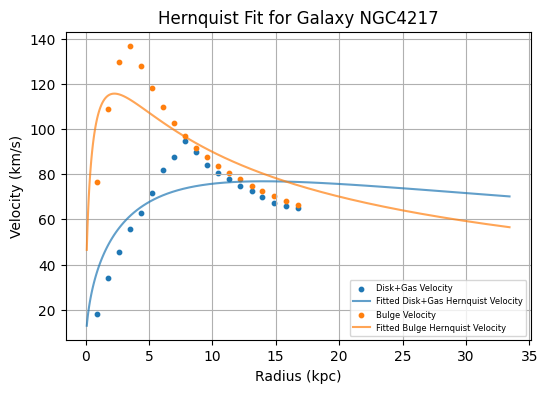

In [2]:
gal = "NGC4217"

gammad, _ = Gamma_disk(gal)
gammab, _ = Gamma_bulge(gal)

fitter = HernquistFit(gal, gamma_star=gammad, gamma_bulge=gammab, method="lmfit")

M_b_fit = fitter.M_b_fit
a_fit = fitter.a_fit
M_b_fit_b = fitter.M_b_fit_bulge
a_fit_b = fitter.a_fit_bulge

r_vals = fitter.r_vals

ri = np.geomspace(0.1, r_vals.max() * 2, 100)

vcds_fit = fitter.vc(ri, M_b=M_b_fit, a=a_fit)
vcb_fit = fitter.vc(ri, M_b=M_b_fit_b, a=a_fit_b)

vcdg = fitter.vc_disk_gas
vcb = fitter.vc_bulge

plt.figure(figsize=(6,4))

plt.scatter(r_vals, vcdg, label='Disk+Gas Velocity', color='C0', s=10)
plt.plot(ri, vcds_fit, label='Fitted Disk+Gas Hernquist Velocity', color='C0', alpha=0.7)
plt.scatter(r_vals, vcb, label='Bulge Velocity', color='C1', s=10)
plt.plot(ri, vcb_fit, label='Fitted Bulge Hernquist Velocity', color='C1', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Hernquist Fit for Galaxy {gal}')
plt.legend(fontsize=6, loc="lower right")
plt.grid()
plt.show()  

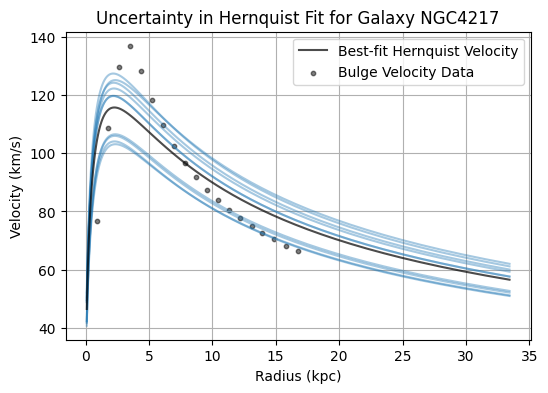

In [8]:
log_M_b_fit = np.log10(M_b_fit_b)
# random values withing -1 and 1
log_M_b_samples = log_M_b_fit + np.random.uniform(-0.1, 0.1, size=10)

a_b_samples = a_fit_b + np.random.uniform(-0.1, 0.1, size=10)

ri = np.geomspace(0.1, r_vals.max() * 2, 100)

vc_fit = fitter.vc(ri, M_b=M_b_fit_b, a=a_fit_b)

plt.figure(figsize=(6,4))
for log_M_b, a_b in zip(log_M_b_samples, a_b_samples):
    M_b = 10**log_M_b
    
    vc = plt.plot(ri, fitter.vc(ri, M_b=M_b, a=a_b), alpha=0.4, color='C0')
    
plt.plot(ri, vc_fit, label='Best-fit Hernquist Velocity', color='k', alpha=0.7)
plt.scatter(r_vals, vcb, label='Bulge Velocity Data', color='k', s=10, alpha=0.5)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Uncertainty in Hernquist Fit for Galaxy {gal}')
plt.legend()
plt.grid()
plt.show()

# Testing the Dehen model

In [6]:
def hernquist_model(r, M_b=1e10, a=1):
    """
    Circular velocity squared for Hernquist profile.
    Takes:
        r : radius [kpc] (or array of radii)
        M_b : total baryonic mass [solar masses]
        a : scale radius [kpc]
    Returns:
        Vc : circular velocity at radius r [km/s]
    """
    G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]
    vc = np.sqrt(G * M_b * r) / (r + a)
    return vc

In [7]:
def dehen_model(r, M_b=1e10, a=1, gamma=1):
    G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]
    vcsq = G * M_b * ((r**(2-gamma)) / (r + a)**(3-gamma))
    return np.sqrt(vcsq)

In [12]:
gal = "UGC09133"
data, _, _ = get_rc_data(gal)
gammad, _ = Gamma_disk(gal)

# Total baryonic circular velocity
def vc_disk_gas(data, gamma_star=0.5):
    radii = data["Rad"].values
    vc_disk_sq = gamma_star * data["Vdisk"] ** 2
    vc_gas_sq = data["Vgas"] ** 2

    vc_baryons = np.sqrt(vc_disk_sq + vc_gas_sq)

    return radii, vc_baryons

r_data, vc_data = vc_disk_gas(data, gamma_star=gammad)

model = Model(dehen_model)
params = model.make_params(M_b=1e10, a=10.0, gamma=-1.0)
# params["gamma"].set(min=-3.0, max=3.0)
result = model.fit(vc_data, params, r=r_data)

M_b_fit_dehen, a_fit_dehen, gamma_fit_dehen = result.params['M_b'].value, result.params['a'].value, result.params['gamma'].value
print(f"Dehnen Fit - M_b: {M_b_fit_dehen:.2e} solar masses, a: {a_fit_dehen:.2f} kpc, gamma: {gamma_fit_dehen:.2f}")


Dehnen Fit - M_b: 2.51e+11 solar masses, a: 2.18 kpc, gamma: -2.10


Fitting with lmfit took 0.0141 seconds
Fitted parameters for galaxy UGC09133 using lmfit:
  M_b = 3.19e+11 solar masses
  a   = 9.99 kpc
  chi-squared = 21484.1253
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0112 seconds
Fitted parameters for galaxy UGC09133 using lmfit:
  M_b = 5.13e+10 solar masses
  a   = 1.16 kpc
  chi-squared = 5723.2150


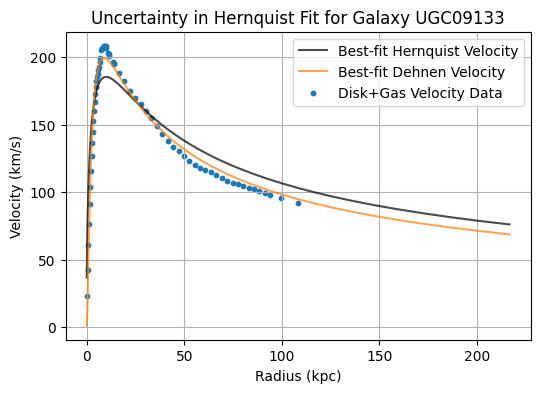

In [13]:
gal = "UGC09133"

gammad, _ = Gamma_disk(gal)
gammab, _ = Gamma_bulge(gal)

fitter = HernquistFit(gal, gamma_star=gammad, gamma_bulge=gammab, method="lmfit")

M_b_fit = fitter.M_b_fit
a_fit = fitter.a_fit
M_b_fit_b = fitter.M_b_fit_bulge
a_fit_b = fitter.a_fit_bulge

r_vals = fitter.r_vals

ri = np.geomspace(0.1, r_vals.max() * 2, 100)

vc_fit = hernquist_model(ri, M_b=M_b_fit, a=a_fit)
vc_fit_dehen = dehen_model(ri, M_b=M_b_fit_dehen, a=a_fit_dehen, gamma=gamma_fit_dehen)
vc = fitter.vc_disk_gas

plt.figure(figsize=(6,4))
plt.plot(ri, vc_fit, label='Best-fit Hernquist Velocity', color='k', alpha=0.7)
plt.plot(ri, vc_fit_dehen, label='Best-fit Dehnen Velocity', color='C1', alpha=0.7)
plt.scatter(r_vals, vc, label='Disk+Gas Velocity Data', color='C0', s=10)
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Uncertainty in Hernquist Fit for Galaxy {gal}')
plt.legend()
plt.grid()
plt.show()

## Potential 

In [11]:
def phi_hern(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func

def phi_dehen(M_b, a, gamma):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        prefactor = - (G * M_b) / (a * (2 - gamma))
        return prefactor * ( 1 - (( r / (r+a) )**(2-gamma)) )

    return phi_func

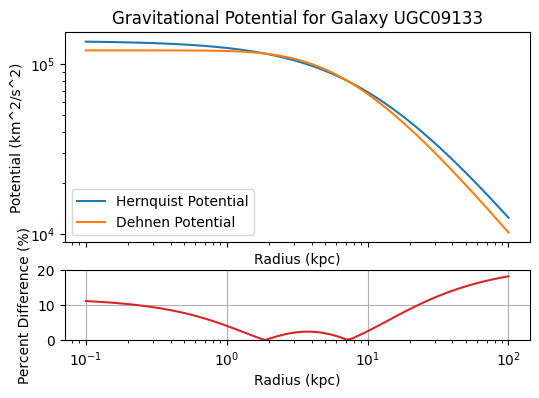

In [16]:
phi_H = phi_hern(M_b_fit, a_fit)
phi_D = phi_dehen(M_b_fit_dehen, a_fit_dehen, gamma_fit_dehen)

ri = np.geomspace(0.1, 100, 100)

phi_H_vals = np.abs(np.array([phi_H(r, 0) for r in ri]))
phi_D_vals = np.abs(np.array([phi_D(r, 0) for r in ri]))
percent_diff = 100 * ( np.abs((phi_H_vals - phi_D_vals)) / np.abs(phi_H_vals) )

# plt.figure(figsize=(6,4))
fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

axs[0].plot(ri, phi_H_vals, label='Hernquist Potential', color='C0')
axs[0].plot(ri, phi_D_vals, label='Dehnen Potential', color='C1')
axs[0].set_xlabel('Radius (kpc)')
axs[0].set_ylabel('Potential (km^2/s^2)')
axs[0].set_title(f'Gravitational Potential for Galaxy {gal}')
axs[0].legend()
axs[1].plot(ri, percent_diff, label='Percent Difference', color='C3')
axs[1].set_xlabel('Radius (kpc)')
axs[1].set_ylabel('Percent Difference (%)')
plt.grid()
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_ylim(0, 20)
plt.show()

## Jeans model 

In [18]:
M200 = 1e12 # solar masses
c = 10 # concentration parameter
rm = 20 

jeans_hern = jeans.squashed(rm, M200, c, Phi_b=phi_H)
jeans_dehen = jeans.squashed(rm, M200, c, Phi_b=phi_D)

if jeans_hern and jeans_dehen:
    print("Jeans profiles computed successfully.")

Jeans profiles computed successfully.


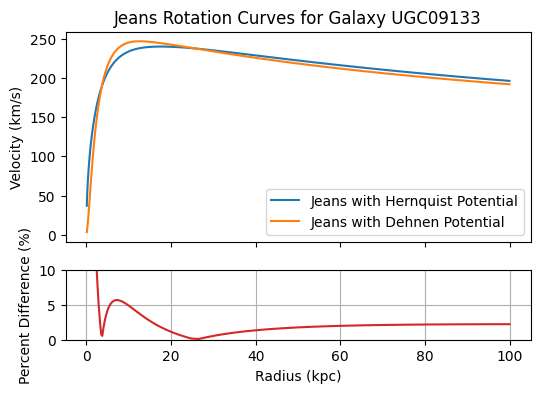

In [24]:
ri = np.geomspace(0.1, 100, 100)
vc_hern = jeans_hern.V(ri, Lmax=0)
vc_dehen = jeans_dehen.V(ri, Lmax=0)
percent_diff_vc = 100 * ( np.abs((vc_hern - vc_dehen)) / np.abs(vc_hern) )

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

axs[0].plot(ri, vc_hern, label='Jeans with Hernquist Potential', color='C0')
axs[0].plot(ri, vc_dehen, label='Jeans with Dehnen Potential', color='C1')
axs[0].set_ylabel('Velocity (km/s)')
axs[0].set_title(f'Jeans Rotation Curves for Galaxy {gal}')
axs[0].legend()
axs[1].plot(ri, percent_diff_vc, label='Percent Difference', color='C3')
axs[1].set_xlabel('Radius (kpc)')
axs[1].set_ylabel('Percent Difference (%)')
axs[1].set_ylim(0, 10)

plt.grid()
plt.show()

# Cuts on the Galaxy IDs 

Apply the following cuts:

1. More than 8 data points 
2. V_vir/V_flat condition -> post mcmc
3. M_b_obs ~ M_b_fit (within 0.5 dex)
3. Worst 20% of fits 

In [2]:
galaxy_ids = get_galaxy_ids()

In [3]:
data_path = os.getcwd() + "/data/fit_data/"

df = pd.read_csv(data_path + "hern_fits.csv")
dfmb = pd.read_csv(data_path + "M_b_comparison.csv")

chisq_series = df['ChiSq'].values
chisq_order = np.argsort(chisq_series)
eigthy_pc = int(0.8 * len(df))
chi_good = df.iloc[chisq_order[:eigthy_pc]]["GalaxyID"].values

results = []

for galaxy_id in galaxy_ids:
    sub = df[df["GalaxyID"] == galaxy_id]
    data, _, _ = get_rc_data(galaxy_id)
    
    # cut 1 
    if len(data) < 8:
        length_cut = 'fail'
    else:
        length_cut = 'pass'
        
    # cut 2
    if galaxy_id in chi_good:
        chi_cut = 'pass'
    else:
        chi_cut = 'fail'
    
    log_M_b_obs = dfmb[dfmb["GalaxyID"] == galaxy_id]["log_M_b"].values[0]
    log_M_b_fit = dfmb[dfmb["GalaxyID"] == galaxy_id]["log_M_b_fit_hern"].values[0]
    
    # cut 3
    if np.abs(log_M_b_fit - log_M_b_obs) < 0.5:
        mb_cut = 'pass'
    else:
        mb_cut = 'fail'
        
    # cut 4
    if np.sum(data['Vbul']) > 0:
        bulge_cut = 'fail'
    else:
        bulge_cut = 'pass'
        
    results.append([galaxy_id, length_cut, chi_cut, mb_cut, bulge_cut])
    
res = pd.DataFrame(results, columns=["GalaxyID", "Length Cut", "ChiSq Cut", "M_b Cut", "Bulge Cut"])

res.to_csv(data_path + "hern_fit_cuts.csv", index=False)

res.head()

,GalaxyID,Length Cut,ChiSq Cut,M_b Cut,Bulge Cut
0,NGC5371,pass,fail,pass,pass
1,UGC05829,pass,pass,fail,pass
2,NGC5005,pass,fail,fail,fail
3,UGCA444,pass,pass,fail,pass
4,NGC1003,pass,pass,pass,pass


In [4]:
data_path = os.getcwd() + "/data/fit_data/"
df = pd.read_csv(data_path + "hern_fit_cuts.csv")

length = (df["Length Cut"] == "pass") 
chi = (df["ChiSq Cut"] == "pass")
mb = (df["M_b Cut"] == "pass")
bulge = (df["Bulge Cut"] == "pass")

len_cut = df[length].shape[0]
chi_cut = df[chi].shape[0]
mb_cut = df[mb].shape[0]
bulge_cut = df[bulge].shape[0]

print(f"Length cut passed: {len_cut} galaxies")
print(f"ChiSq cut passed: {chi_cut} galaxies")
print(f"M_b cut passed: {mb_cut} galaxies")
print(f"Bulge cut passed: {bulge_cut} galaxies")

all_cuts = length & chi & bulge & mb
final_count = df[all_cuts].shape[0]

print(f"All cuts passed: {final_count} galaxies")

base_cuts = length & bulge 
len_n_bulge = df[base_cuts].shape[0]

print(f"Length and no bulge: {len_n_bulge} galaxies")

Length cut passed: 143 galaxies
ChiSq cut passed: 140 galaxies
M_b cut passed: 68 galaxies
Bulge cut passed: 143 galaxies
All cuts passed: 30 galaxies
Length and no bulge: 112 galaxies


In [5]:
df = pd.read_csv(data_path + "dehnen_fits.csv")
dfmb = pd.read_csv(data_path + "M_b_comparison.csv")

chisq_series = df['ChiSq'].values
chisq_order = np.argsort(chisq_series)
eigthy_pc = int(0.8 * len(df))
chi_good = df.iloc[chisq_order[:eigthy_pc]]["GalaxyID"].values

results = []

for galaxy_id in galaxy_ids:
    sub = df[df["GalaxyID"] == galaxy_id]
    data, _, _ = get_rc_data(galaxy_id)
    
    # cut 1 
    if len(data) < 8:
        length_cut = 'fail'
    else:
        length_cut = 'pass'
        
    # cut 2
    if galaxy_id in chi_good:
        chi_cut = 'pass'
    else:
        chi_cut = 'fail'
    
    log_M_b_obs = dfmb[dfmb["GalaxyID"] == galaxy_id]["log_M_b"].values[0]
    log_M_b_fit = dfmb[dfmb["GalaxyID"] == galaxy_id]["log_M_b_fit_dehnen"].values[0]
    
    # cut 3
    if np.abs(log_M_b_fit - log_M_b_obs) < 0.5:
        mb_cut = 'pass'
    else:
        mb_cut = 'fail'
        
    # cut 4
    if np.sum(data['Vbul']) > 0:
        bulge_cut = 'fail'
    else:
        bulge_cut = 'pass'
        
    results.append([galaxy_id, length_cut, chi_cut, mb_cut, bulge_cut])
    
res = pd.DataFrame(results, columns=["GalaxyID", "Length Cut", "ChiSq Cut", "M_b Cut", "Bulge Cut"])

res.to_csv(data_path + "dehnen_fit_cuts.csv", index=False)

res.head()

,GalaxyID,Length Cut,ChiSq Cut,M_b Cut,Bulge Cut
0,NGC5371,pass,fail,pass,pass
1,UGC05829,pass,pass,fail,pass
2,NGC5005,pass,pass,pass,fail
3,UGCA444,pass,pass,fail,pass
4,NGC1003,pass,pass,pass,pass


In [6]:
data_path = os.getcwd() + "/data/fit_data/"
df = pd.read_csv(data_path + "dehnen_fit_cuts.csv")

length = (df["Length Cut"] == "pass") 
chi = (df["ChiSq Cut"] == "pass")
mb = (df["M_b Cut"] == "pass")
bulge = (df["Bulge Cut"] == "pass")

len_cut = df[length].shape[0]
chi_cut = df[chi].shape[0]
mb_cut = df[mb].shape[0]
bulge_cut = df[bulge].shape[0]

print(f"Length cut passed: {len_cut} galaxies")
print(f"ChiSq cut passed: {chi_cut} galaxies")
print(f"M_b cut passed: {mb_cut} galaxies")
print(f"Bulge cut passed: {bulge_cut} galaxies")

all_cuts = length & chi & bulge & mb
final_count = df[all_cuts].shape[0]

print(f"All cuts passed: {final_count} galaxies")

base_cuts = length & bulge
len_n_bulge = df[base_cuts].shape[0]

print(f"Length and no bulge: {len_n_bulge} galaxies")

Length cut passed: 143 galaxies
ChiSq cut passed: 140 galaxies
M_b cut passed: 86 galaxies
Bulge cut passed: 143 galaxies
All cuts passed: 32 galaxies
Length and no bulge: 112 galaxies


In [8]:
dfmb = df[mb]
dfmb.GalaxyID.values

array(['NGC5371', 'NGC5005', 'NGC1003', 'NGC0100', 'UGC07261', 'NGC6195',
       'NGC4183', 'UGC08699', 'F583-4', 'NGC2841', 'NGC2403', 'NGC0300',
       'NGC4214', 'PGC51017', 'NGC2915', 'UGC08490', 'UGC05721',
       'ESO563-G021', 'ESO116-G012', 'NGC3521', 'NGC1090', 'NGC3893',
       'NGC3726', 'UGC12506', 'UGC11455', 'NGC1705', 'UGC06818',
       'UGC05253', 'UGC03546', 'NGC6503', 'UGC07690', 'UGC00634',
       'DDO154', 'UGC07603', 'NGC3992', 'NGC4088', 'ESO444-G084',
       'NGC5055', 'NGC0801', 'NGC6946', 'UGC06614', 'NGC3769', 'NGC4085',
       'NGC3198', 'NGC5033', 'UGC02885', 'NGC5907', 'NGC0289', 'UGC06973',
       'UGC02487', 'UGC09037', 'F571-8', 'D564-8', 'NGC2998', 'NGC2683',
       'NGC5585', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'D631-7',
       'NGC2955', 'UGC03580', 'NGC4100', 'UGC06786', 'NGC6674', 'NGC6015',
       'DDO168', 'NGC2903', 'UGC02455', 'UGC05986', 'UGCA281', 'UGC09133',
       'NGC0024', 'UGC08550', 'UGC02953', 'NGC4138', 'NGC4559', 'NGC4013',


The chi cut is not independent. It should be done last with the final list of Galaxy IDs. 

In [15]:
all_cuts = length & mb 
final_count = df[all_cuts].shape[0]

print(f"All cuts passed: {final_count} galaxies")

All cuts passed: 63 galaxies


# Check Gravothermal list against M_b cuts

In [3]:
data_path = os.getcwd() + "/../data/fit_data/"

df = pd.read_csv(data_path + "M_b_comparison.csv")

df.head()

,GalaxyID,log_M_b_fit_hern,log_M_b_fit_dehnen,log_M_b
0,NGC5371,11.528797,11.600694,11.198234
1,UGC05829,11.612247,12.805915,9.216863
2,NGC5005,11.482694,11.312736,10.975568
3,UGCA444,9.825136,8.962598,7.977736
4,NGC1003,10.139853,10.109986,10.099083


In [4]:
gravo_list = ["DDO154", "ESO444-G084", "F568-V1", "F574-1", "NGC0300", "NGC3109", "UGC00128", "UGC06446", "UGC06667", "UGC08286", "NGC4376", "NGC4396", "NGC7320", "UGC04169"]

sparc_list = df.GalaxyID.values

for g in gravo_list:
    if g in sparc_list:
        print(f"{g} is in both Gravo and SPARC")
    else:
        print(f"{g} is only in Gravo")

DDO154 is in both Gravo and SPARC
ESO444-G084 is in both Gravo and SPARC
F568-V1 is in both Gravo and SPARC
F574-1 is in both Gravo and SPARC
NGC0300 is in both Gravo and SPARC
NGC3109 is in both Gravo and SPARC
UGC00128 is in both Gravo and SPARC
UGC06446 is in both Gravo and SPARC
UGC06667 is in both Gravo and SPARC
UGC08286 is in both Gravo and SPARC
NGC4376 is only in Gravo
NGC4396 is only in Gravo
NGC7320 is only in Gravo
UGC04169 is only in Gravo


In [9]:
df["diff_dehnen"] = df["log_M_b_fit_dehnen"] - df["log_M_b"]

In [5]:
dfs = df[df["GalaxyID"].isin(gravo_list)]

In [7]:
dfs.GalaxyID.values

array(['UGC06667', 'F574-1', 'NGC0300', 'UGC06446', 'DDO154',
       'ESO444-G084', 'F568-V1', 'UGC00128', 'UGC08286', 'NGC3109'],
      dtype=object)

# List of good galaxies

## Vflat bins

In [44]:
galaxy_ids = get_galaxy_ids()

In [45]:
v_flat_vals = []

for g in galaxy_ids:
    df, _ = get_mass_data(g)
    v_flat = df['Vflat'].values[0]
    Q = df['Q'].values[0]
    v_flat_vals.append([g, v_flat, Q])
    
dfv = pd.DataFrame(v_flat_vals, columns=["GalaxyID", "Vflat", "Q"])
dfv.head()

,GalaxyID,Vflat,Q
0,NGC5371,209.5,1
1,UGC05829,0.0,2
2,NGC5005,262.2,1
3,UGCA444,37.0,2
4,NGC1003,109.8,1


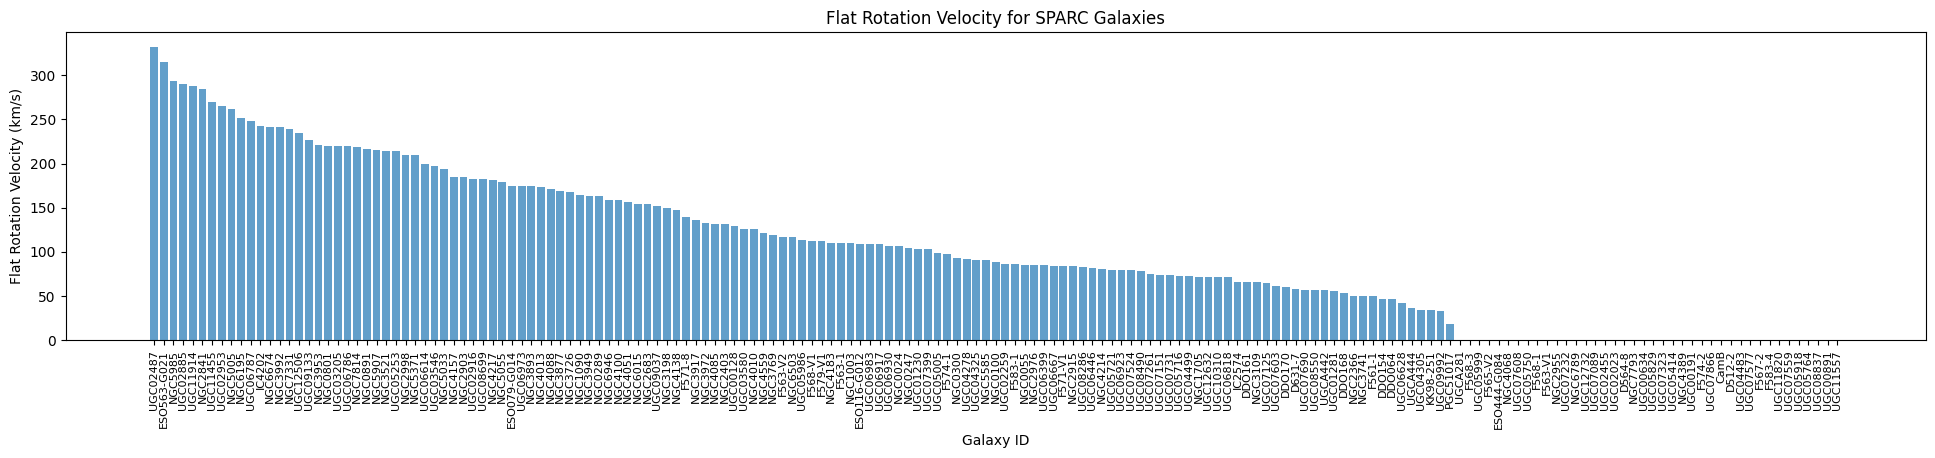

In [11]:
plt.figure(figsize=(24,4))

df = df.sort_values("Vflat", ascending=False)

# plot v_flat for all galaxies with galaxy id on x-axis
plt.bar(df["GalaxyID"], df["Vflat"], color='C0', alpha=0.7)
plt.xlabel('Galaxy ID')
plt.ylabel('Flat Rotation Velocity (km/s)')
plt.title('Flat Rotation Velocity for SPARC Galaxies')
plt.xticks(rotation=90, fontsize=8)
# plt.grid()
plt.show()

In [46]:
logM200_vals = []

for g in galaxy_ids:
    log_M200, _ = log_M200_weighted_mean(g)
    logM200_vals.append([g, log_M200])
    
df = pd.DataFrame(logM200_vals, columns=["GalaxyID", "log_M200"])

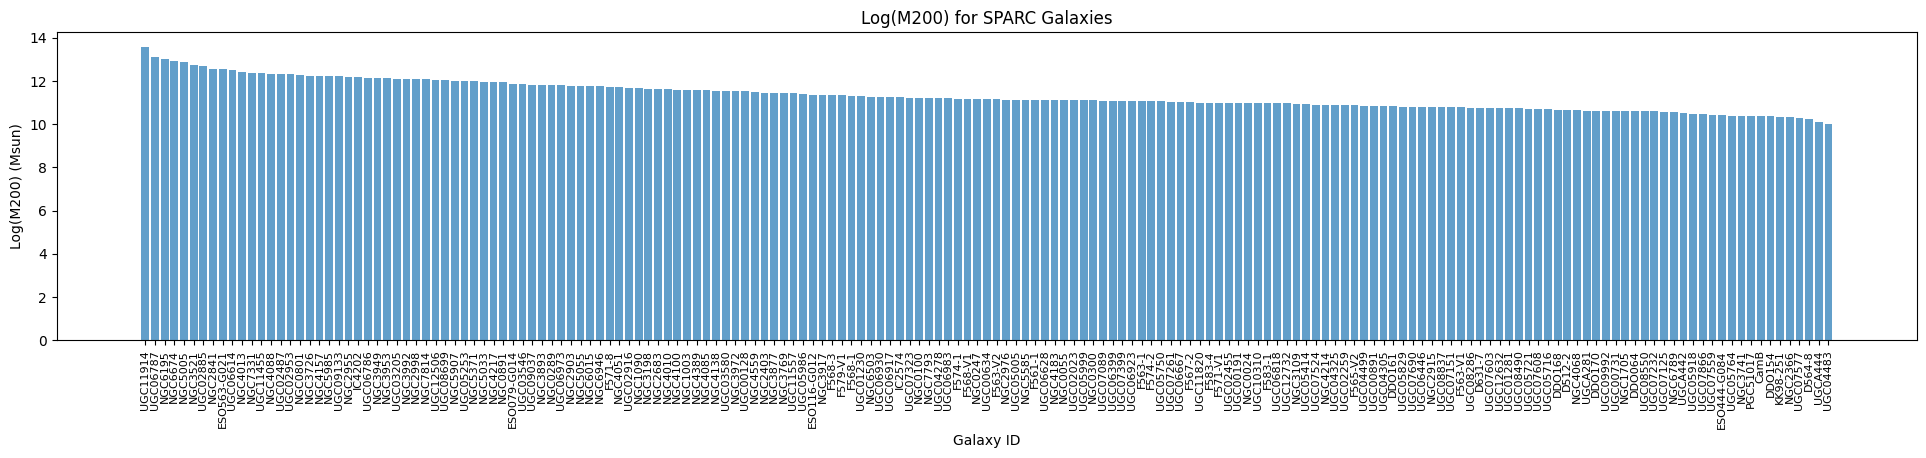

In [4]:
plt.figure(figsize=(24,4))

df = df.sort_values("log_M200", ascending=False)

# plot log_M200 for all galaxies with galaxy id on x-axis
plt.bar(df["GalaxyID"], df["log_M200"], color='C0', alpha=0.7)
plt.xlabel('Galaxy ID')
plt.ylabel('Log(M200) (Msun)')
plt.title('Log(M200) for SPARC Galaxies')
plt.xticks(rotation=90, fontsize=8)
# plt.grid()
plt.show()

In [47]:
# add the Vflat to the log_M200 dataframe 

df = df.merge(dfv, on="GalaxyID")

df.head()

,GalaxyID,log_M200,Vflat,Q
0,NGC5371,11.985129,209.5,1
1,UGC05829,10.810712,0.0,2
2,NGC5005,12.855939,262.2,1
3,UGCA444,10.097947,37.0,2
4,NGC1003,11.587736,109.8,1


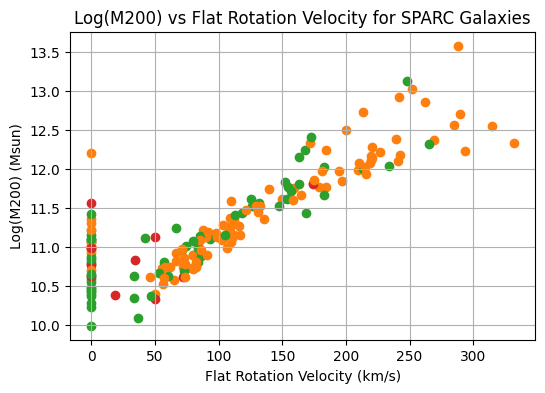

In [13]:
plt.figure(figsize=(6,4))

for g in galaxy_ids:
    df_i = df[df["GalaxyID"] == g]
    plt.scatter(df_i["Vflat"], df_i["log_M200"], color=f'C{df_i["Q"].values[0]}')

plt.xlabel('Flat Rotation Velocity (km/s)')
plt.ylabel('Log(M200) (Msun)')
plt.title('Log(M200) vs Flat Rotation Velocity for SPARC Galaxies')
plt.grid()
plt.show()

In [16]:
len(df[df['Vflat']==0.0])

40

In [20]:
bin_edges = [10, 11, 12, 13]

df['M200_bin'] = pd.cut(df['log_M200'], bins=bin_edges, labels=['10-11', '11-12', '12-13'])

df.head()

,GalaxyID,log_M200,Vflat,Q,M200_bin
0,NGC5371,11.985129,209.5,1,11-12
1,UGC05829,10.810712,0.0,2,10-11
2,NGC5005,12.855939,262.2,1,12-13
3,UGCA444,10.097947,37.0,2,10-11
4,NGC1003,11.587736,109.8,1,11-12


In [24]:
df[df["M200_bin"] == '12-13'].shape[0]

30

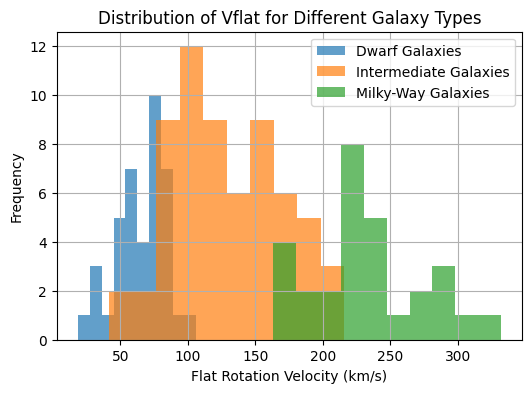

In [30]:
dwf_df = df[df["M200_bin"] == '10-11']
int_df = df[df["M200_bin"] == '11-12']
mw_df = df[df["M200_bin"] == '12-13']

# drop Vflat == 0 from each dataframe
dwf_df = dwf_df[dwf_df['Vflat'] > 0]
int_df = int_df[int_df['Vflat'] > 0]
mw_df = mw_df[mw_df['Vflat'] > 0]


plt.figure(figsize=(6,4))

plt.hist(dwf_df["Vflat"], bins=10, alpha=0.7, label='Dwarf Galaxies')
plt.hist(int_df["Vflat"], bins=10, alpha=0.7, label='Intermediate Galaxies')
plt.hist(mw_df["Vflat"], bins=10, alpha=0.7, label='Milky-Way Galaxies')
plt.xlabel('Flat Rotation Velocity (km/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Vflat for Different Galaxy Types')
plt.legend()
plt.grid()
plt.show()

In [36]:
bin_edges = [30, 70, 120, 180, 260, 400]

df['Vflat_bin'] = pd.cut(df['Vflat'], bins=bin_edges, labels=['30-70', '70-120', '120-180', '180-260', '>260'])

df.head()

,GalaxyID,log_M200,Vflat,Q,M200_bin,Vflat_bin
0,NGC5371,11.985129,209.5,1,11-12,180-260
1,UGC05829,10.810712,0.0,2,10-11,NaN
2,NGC5005,12.855939,262.2,1,12-13,>260
3,UGCA444,10.097947,37.0,2,10-11,30-70
4,NGC1003,11.587736,109.8,1,11-12,70-120


In [43]:
df

,GalaxyID,log_M200,Vflat,Q,M200_bin,Vflat_bin
0,NGC5371,11.985129,209.5,1,11-12,180-260
2,NGC5005,12.855939,262.2,1,12-13,>260
3,UGCA444,10.097947,37.0,2,10-11,30-70
4,NGC1003,11.587736,109.8,1,11-12,70-120
6,NGC0100,11.215437,88.1,1,11-12,70-120
...,...,...,...,...,...,...
167,NGC4217,11.967907,181.3,1,11-12,180-260
168,NGC3109,10.930593,66.2,1,10-11,30-70
170,NGC3949,12.152832,163.0,2,12-13,120-180
173,NGC4157,12.241194,184.7,1,12-13,180-260


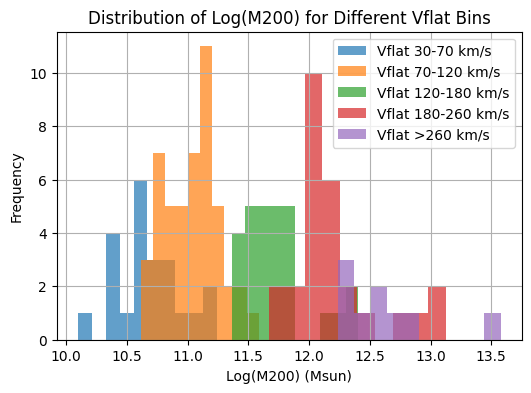

In [38]:
df = df[df['Vflat'] > 0]

df_30_70 = df[df['Vflat_bin'] == '30-70']
df_70_120 = df[df['Vflat_bin'] == '70-120']
df_120_180 = df[df['Vflat_bin'] == '120-180']
df_180_260 = df[df['Vflat_bin'] == '180-260']
df_260 = df[df['Vflat_bin'] == '>260']

plt.figure(figsize=(6,4))
plt.hist(df_30_70["log_M200"], bins=10, alpha=0.7, label='Vflat 30-70 km/s')
plt.hist(df_70_120["log_M200"], bins=10, alpha=0.7, label='Vflat 70-120 km/s')
plt.hist(df_120_180["log_M200"], bins=10, alpha=0.7, label='Vflat 120-180 km/s')
plt.hist(df_180_260["log_M200"], bins=10, alpha=0.7, label='Vflat 180-260 km/s')
plt.hist(df_260["log_M200"], bins=10, alpha=0.7, label='Vflat >260 km/s')
plt.xlabel('Log(M200) (Msun)')
plt.ylabel('Frequency')
plt.title('Distribution of Log(M200) for Different Vflat Bins')
plt.legend()
plt.grid()
plt.show()

In [39]:
print(f"Number of galaxies in the 30-70 range: {df_30_70.shape[0]}")
print(f"Number of galaxies in the 70-120 range: {df_70_120.shape[0]}")
print(f"Number of galaxies in the 120-180 range: {df_120_180.shape[0]}")
print(f"Number of galaxies in the 180-260 range: {df_180_260.shape[0]}")
print(f"Number of galaxies in the >260 range: {df_260.shape[0]}")

Number of galaxies in the 30-70 range: 22
Number of galaxies in the 70-120 range: 48
Number of galaxies in the 120-180 range: 28
Number of galaxies in the 180-260 range: 27
Number of galaxies in the >260 range: 9


## Trying the Ren et al bins instead 

In [ ]:
galaxy_ids = get_galaxy_ids()

results = []

bin_labels = ["79-91", "91-126", "139-172", "239-315"]

for g in galaxy_ids:
    df_i = df[df["GalaxyID"] == g]
    vflat = df_i["Vflat"].values[0]
   
    if vflat >= 79 and vflat < 91:
        vflat_bin = "79-91"
    elif vflat >= 91 and vflat <= 126:
        vflat_bin = "91-126"
    elif vflat >= 139 and vflat <= 172:
        vflat_bin = "139-172"
    elif vflat >= 239 and vflat <= 315:
        vflat_bin = "239-315"
    else:
        vflat_bin = np.nan
        
    results.append([g, vflat_bin])
    
vflat_bins = pd.DataFrame(results, columns=["GalaxyID", "Vflat_bin"])

In [50]:
df = df.merge(vflat_bins, on="GalaxyID")
df

,GalaxyID,log_M200,Vflat,Q,Vflat_bin
0,NGC5371,11.985129,209.5,1,NaN
1,UGC05829,10.810712,0.0,2,NaN
2,NGC5005,12.855939,262.2,1,239-315
3,UGCA444,10.097947,37.0,2,NaN
4,NGC1003,11.587736,109.8,1,91-126
...,...,...,...,...,...
170,NGC3949,12.152832,163.0,2,139-172
171,D512-2,10.654751,0.0,2,NaN
172,NGC4389,11.566166,0.0,3,NaN
173,NGC4157,12.241194,184.7,1,NaN


In [60]:
sub = df[df["Q"] > 0]
len(sub)

175

In [61]:
sub.groupby("Vflat_bin").size()

Vflat_bin
139-172    15
239-315    14
79-91      17
91-126     23
dtype: int64

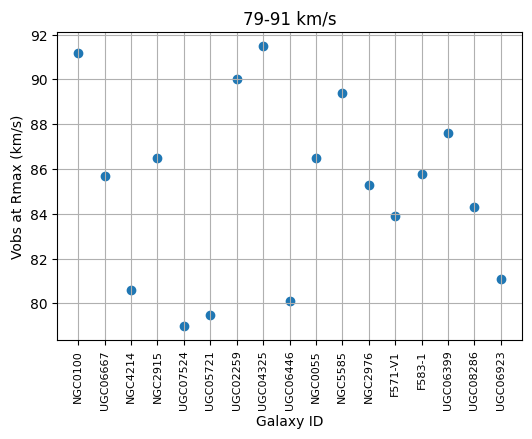

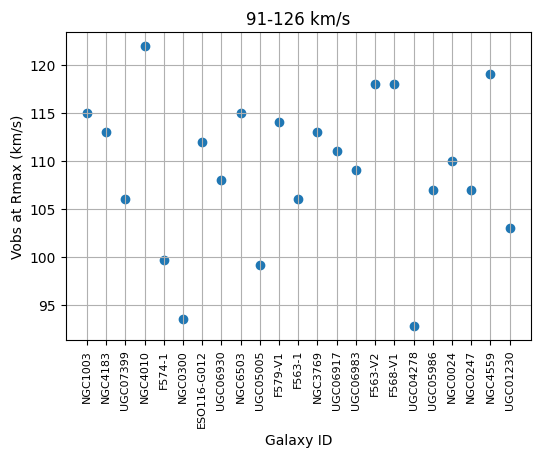

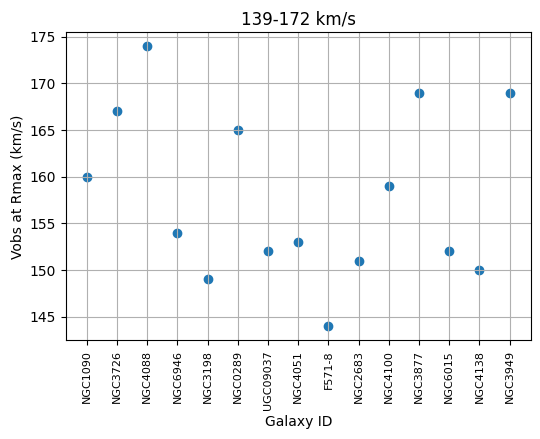

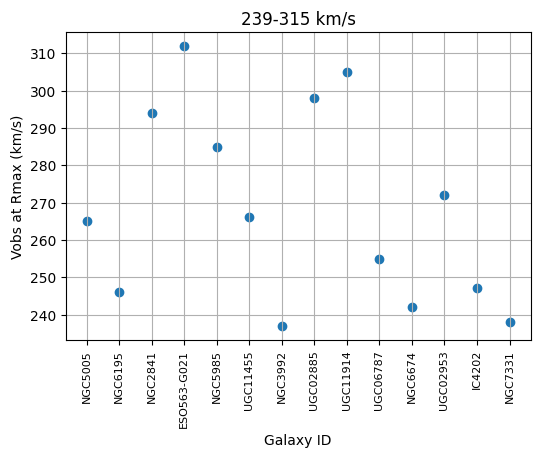

In [56]:
bin_labels = ["79-91", "91-126", "139-172", "239-315"]

for bin in bin_labels:
    subset = df[df["Vflat_bin"] == bin]
    plt.figure(figsize=(6,4))
    galaxies = subset["GalaxyID"].values
    for g in galaxies:
        vc_data, _, _ = get_rc_data(g)
        r_max = vc_data["Rad"].max()
        vc_r_max = vc_data[vc_data["Rad"] == r_max]["Vobs"].values[0]
        plt.scatter(g, vc_r_max, color='C0')
        
    plt.title(f'{bin} km/s')
    plt.xlabel('Galaxy ID')
    plt.ylabel('Vobs at Rmax (km/s)')
    plt.xticks(rotation=90, fontsize=8)
    plt.grid()
    plt.show()
    plt.close()

In [62]:
# get galaxy lists for each vflat bin
bin_labels = ["79-91", "91-126", "139-172", "239-315"]

galaxy_bins = {}

for bin in bin_labels:
    subset = df[df["Vflat_bin"] == bin]
    galaxy_bins[bin] = subset["GalaxyID"].values
    
galaxy_bins

{'79-91': array(['NGC0100', 'UGC06667', 'NGC4214', 'NGC2915', 'UGC07524',
        'UGC05721', 'UGC02259', 'UGC04325', 'UGC06446', 'NGC0055',
        'NGC5585', 'NGC2976', 'F571-V1', 'F583-1', 'UGC06399', 'UGC08286',
        'UGC06923'], dtype=object),
 '91-126': array(['NGC1003', 'NGC4183', 'UGC07399', 'NGC4010', 'F574-1', 'NGC0300',
        'ESO116-G012', 'UGC06930', 'NGC6503', 'UGC05005', 'F579-V1',
        'F563-1', 'NGC3769', 'UGC06917', 'UGC06983', 'F563-V2', 'F568-V1',
        'UGC04278', 'UGC05986', 'NGC0024', 'NGC0247', 'NGC4559',
        'UGC01230'], dtype=object),
 '139-172': array(['NGC1090', 'NGC3726', 'NGC4088', 'NGC6946', 'NGC3198', 'NGC0289',
        'UGC09037', 'NGC4051', 'F571-8', 'NGC2683', 'NGC4100', 'NGC3877',
        'NGC6015', 'NGC4138', 'NGC3949'], dtype=object),
 '239-315': array(['NGC5005', 'NGC6195', 'NGC2841', 'ESO563-G021', 'NGC5985',
        'UGC11455', 'NGC3992', 'UGC02885', 'UGC11914', 'UGC06787',
        'NGC6674', 'UGC02953', 'IC4202', 'NGC7331'], dtype

In [96]:
galaxy_bin_selects = {"79-91": np.array(["UGC06667", "NGC2915", "NGC0055", "UGC08286", "UGC05721"], dtype=object),
                      "91-126": np.array(["NGC4183", "F574-1", "ESO116-G012", "NGC6503", "UGC05005"], dtype=object),
                      "139-172": np.array(["NGC1090", "F571-8", "NGC3877", "NGC3198", "NGC6015"], dtype=object),
                      "239-315": np.array(["ESO563-G021", "NGC6674", "NGC7331", "IC4202", "NGC2841"], dtype=object)}

galaxy_bin_selects

{'79-91': array(['UGC06667', 'NGC2915', 'NGC0055', 'UGC08286', 'UGC05721'],
       dtype=object),
 '91-126': array(['NGC4183', 'F574-1', 'ESO116-G012', 'NGC6503', 'UGC05005'],
       dtype=object),
 '139-172': array(['NGC1090', 'F571-8', 'NGC3877', 'NGC3198', 'NGC6015'], dtype=object),
 '239-315': array(['ESO563-G021', 'NGC6674', 'NGC7331', 'IC4202', 'NGC2841'],
       dtype=object)}

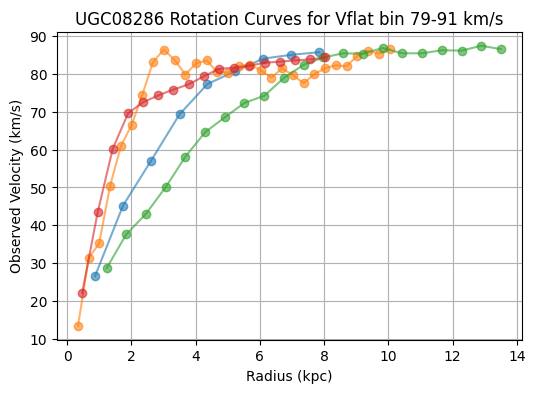

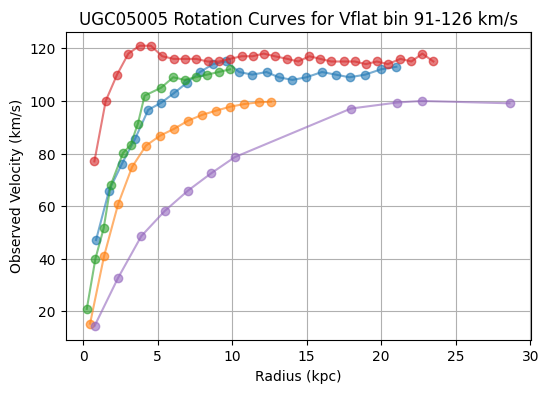

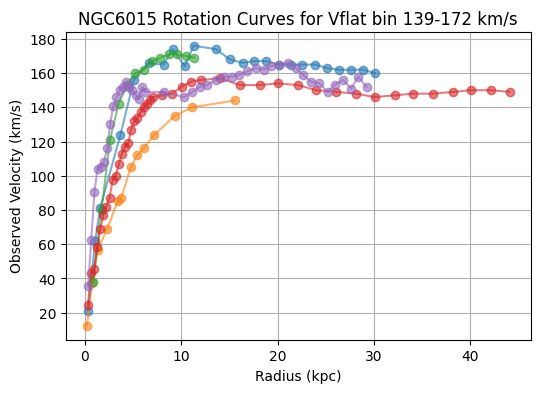

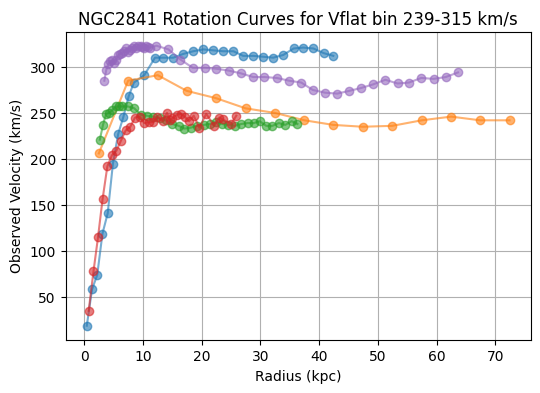

In [89]:
ymaxs = [110, 130, 200, 320]
x_v_lines = [2, 5, 5, 5]
x_maxs = [20, 30, 40, 50]
for idx, key in enumerate(bin_labels):
    galaxies = galaxy_bin_selects[key]
    plt.figure(figsize=(6,4))
    for g in galaxies:
        df, _, _ = get_rc_data(g)
        plt.plot(df["Rad"], df["Vobs"], marker='o', linestyle='-', alpha=0.6)
        # plt.axvline(x=x_v_lines[idx], color='k', linestyle='--', alpha=0.7)
    plt.title(f'{g} Rotation Curves for Vflat bin {key} km/s')
    plt.xlabel('Radius (kpc)')
    plt.ylabel('Observed Velocity (km/s)')
    # plt.ylim(0, ymaxs[idx])
    # plt.xlim(0, x_maxs[idx])
    plt.grid()
    plt.show()
    plt.close()    

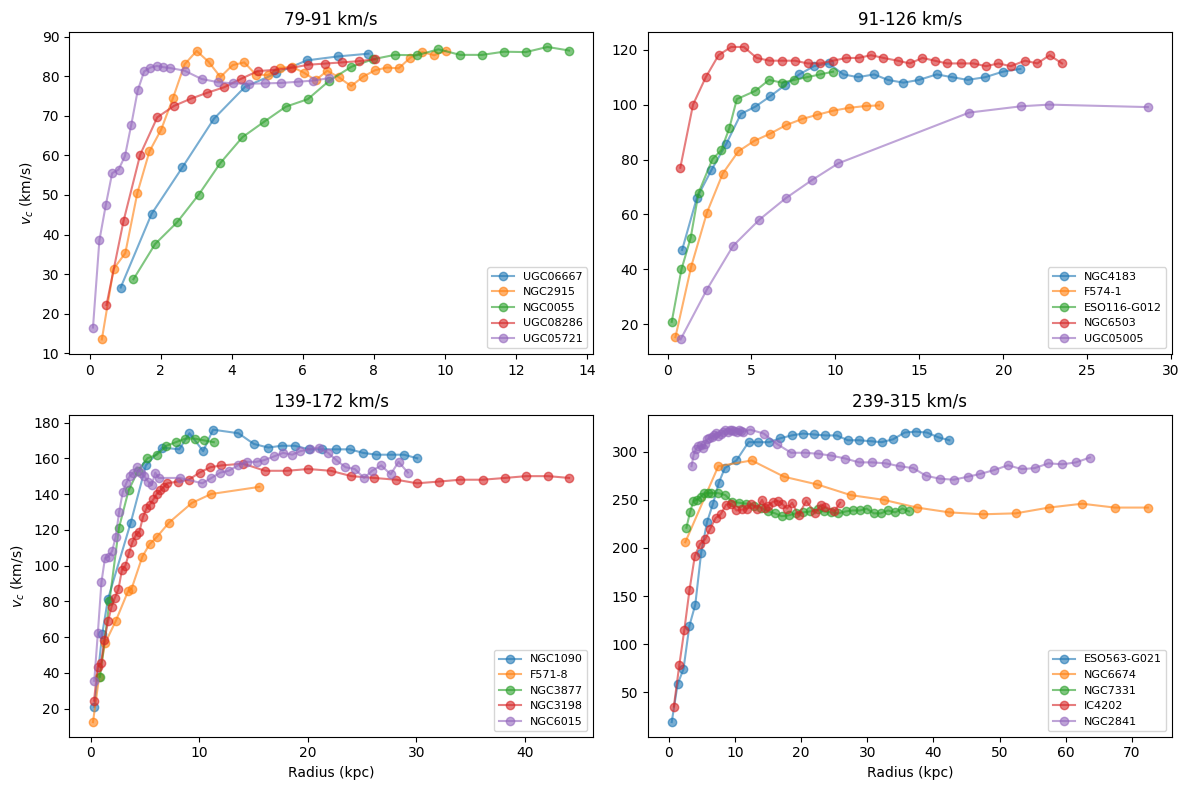

In [98]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

galaxies = galaxy_bin_selects["79-91"]
for g in galaxies:
    df, _, _ = get_rc_data(g)
    axs[0,0].plot(df["Rad"], df["Vobs"], marker='o', linestyle='-', alpha=0.6, label=g)
    axs[0,0].set_title('79-91 km/s')
    # axs[0,0].set_xlabel('Radius (kpc)')
    axs[0,0].set_ylabel(r'$v_c$ (km/s)')
    axs[0,0].legend(fontsize=8, loc="lower right")
    # axs[0,0].grid()
    
galaxies = galaxy_bin_selects["91-126"]
for g in galaxies:
    df, _, _ = get_rc_data(g)
    axs[0,1].plot(df["Rad"], df["Vobs"], marker='o', linestyle='-', alpha=0.6, label=g)
    axs[0,1].set_title('91-126 km/s')
    # axs[0,1].set_xlabel('Radius (kpc)')
    # axs[0,1].set_ylabel(r'$v_c$ (km/s)')
    axs[0,1].legend(fontsize=8, loc="lower right")
    # axs[0,1].grid()
    
galaxies = galaxy_bin_selects["139-172"]
for g in galaxies:
    df, _, _ = get_rc_data(g)
    axs[1,0].plot(df["Rad"], df["Vobs"], marker='o', linestyle='-', alpha=0.6, label=g)
    axs[1,0].set_title('139-172 km/s')
    axs[1,0].set_xlabel('Radius (kpc)')
    axs[1,0].set_ylabel(r'$v_c$ (km/s)')
    axs[1,0].legend(fontsize=8, loc="lower right")
    # axs[1,0].grid()
    
galaxies = galaxy_bin_selects["239-315"]
for g in galaxies:
    df, _, _ = get_rc_data(g)
    axs[1,1].plot(df["Rad"], df["Vobs"], marker='o', linestyle='-', alpha=0.6, label=g)
    axs[1,1].set_title('239-315 km/s')
    axs[1,1].set_xlabel('Radius (kpc)')
    # axs[1,1].set_ylabel(r'$v_c$ (km/s)')
    axs[1,1].legend(fontsize=8, loc="lower right")
    # axs[1,1].grid()
    
plt.tight_layout()
plt.show()

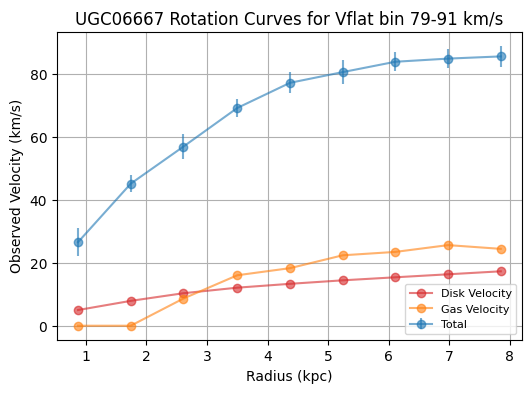

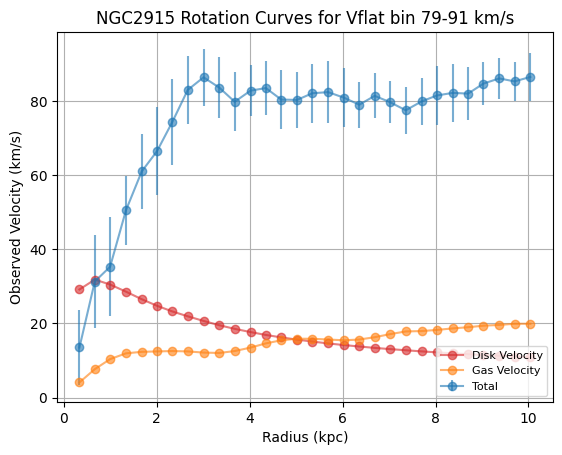

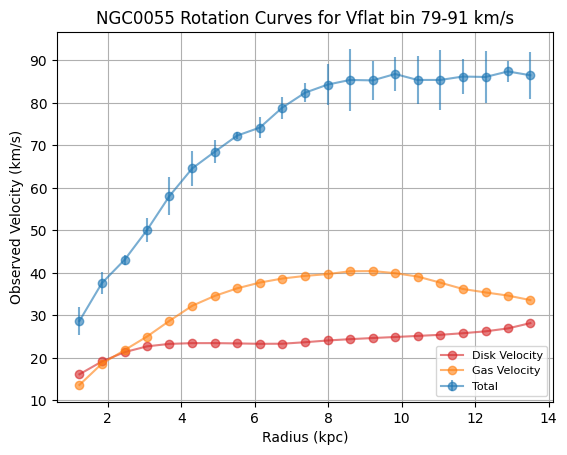

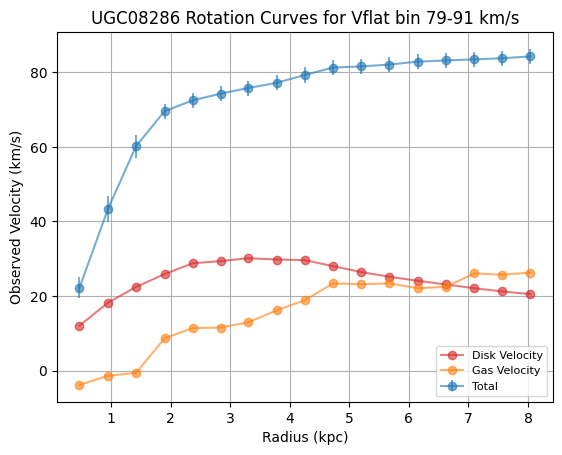

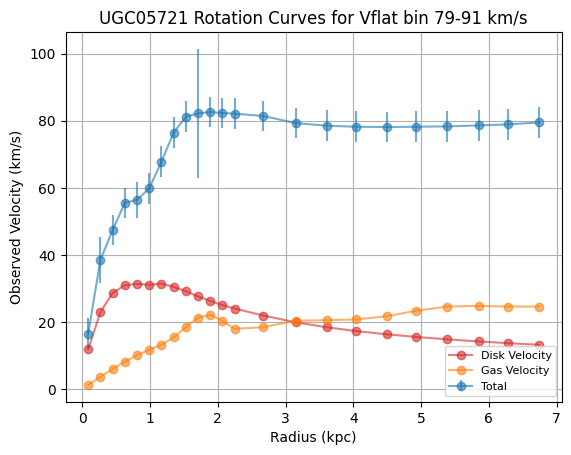

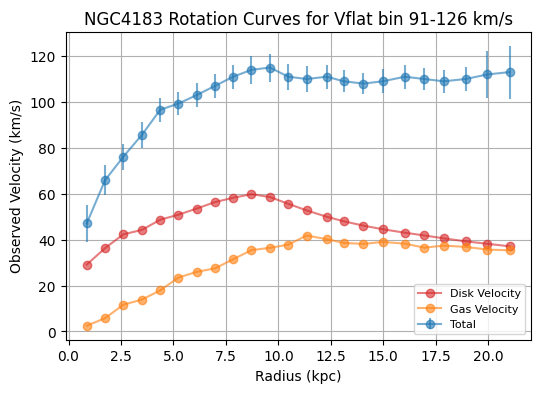

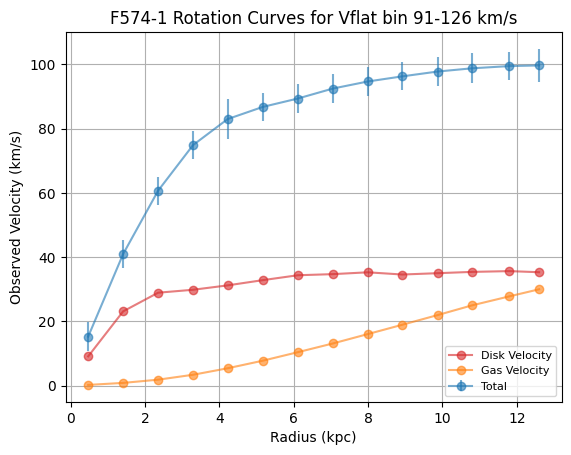

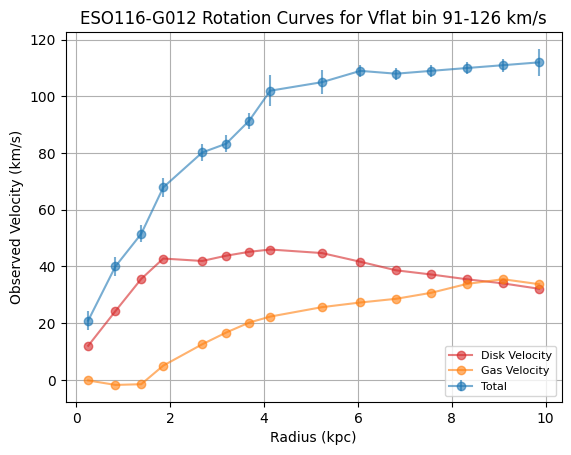

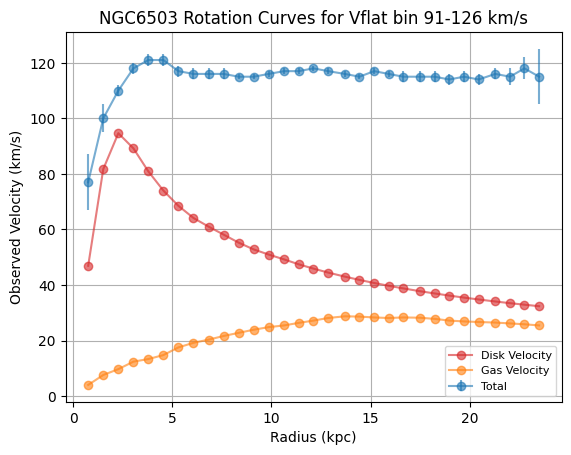

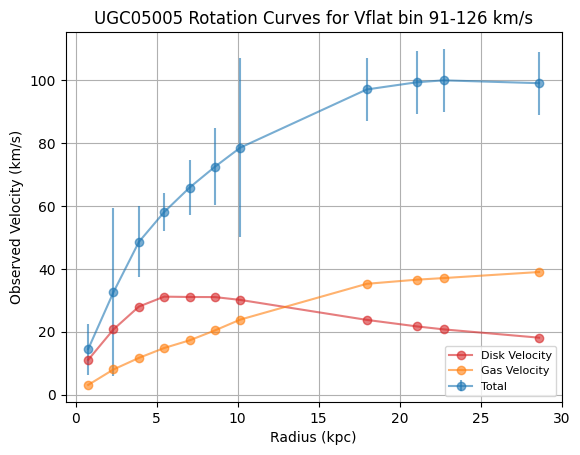

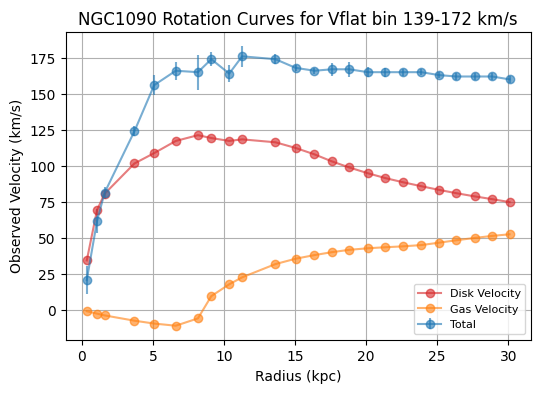

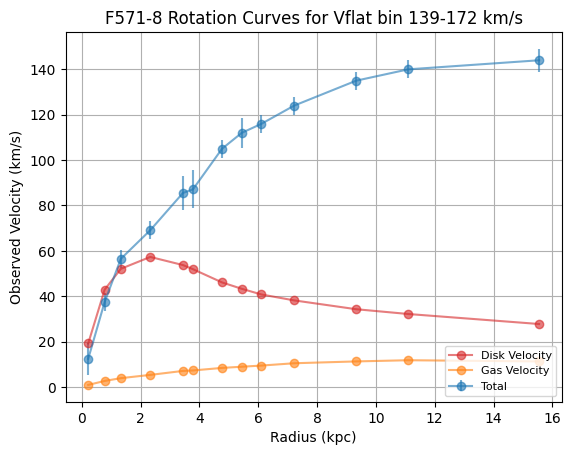

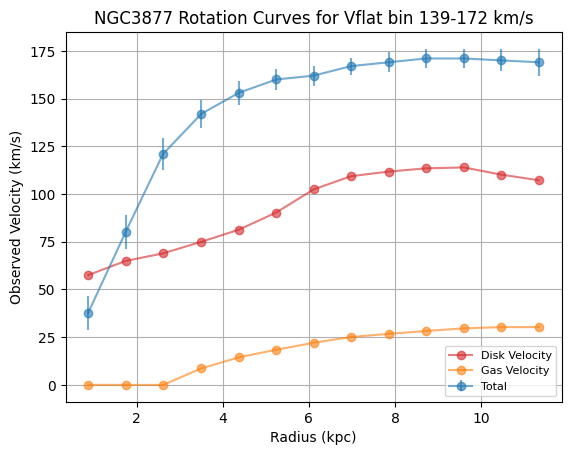

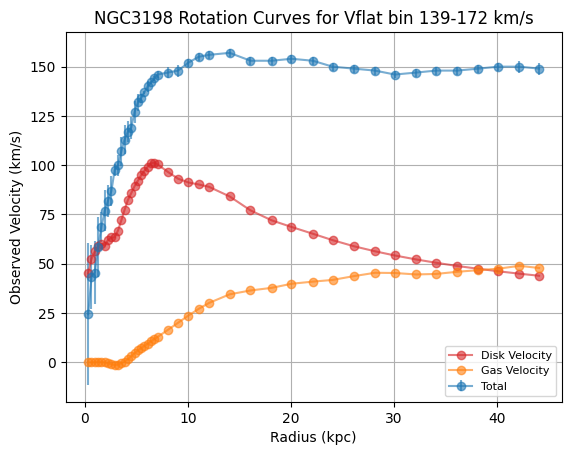

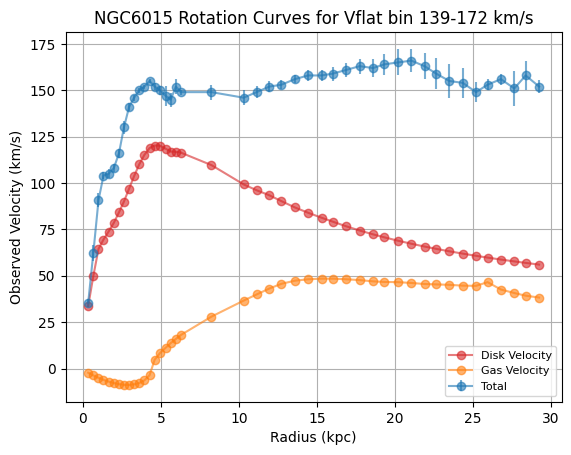

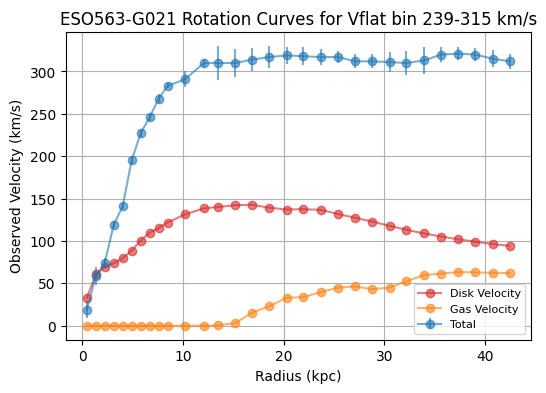

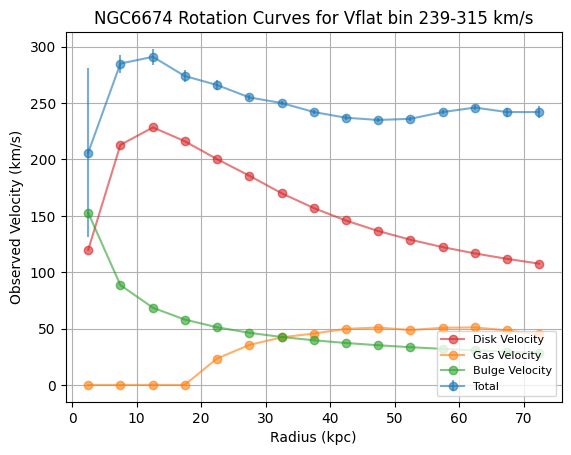

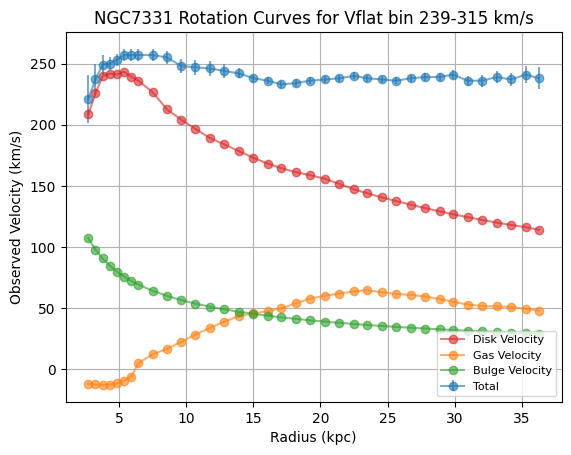

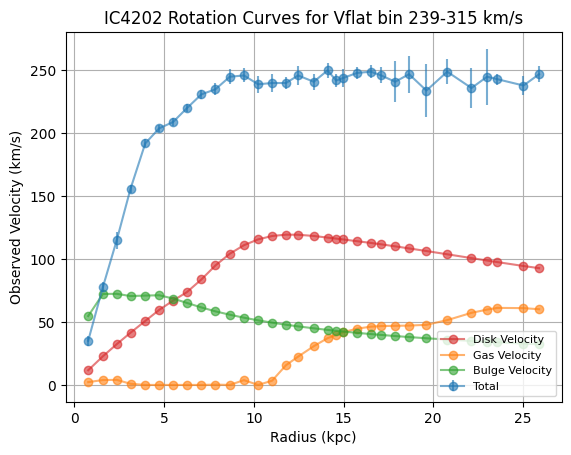

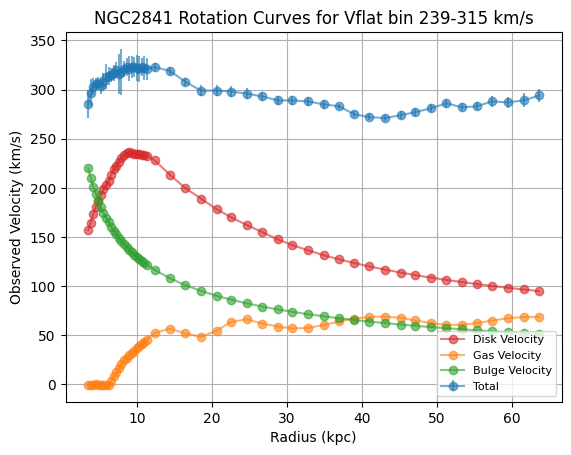

In [101]:
for idx, key in enumerate(bin_labels):
    galaxies = galaxy_bin_selects[key]
    plt.figure(figsize=(6,4))
    for g in galaxies:
        df, _, _ = get_rc_data(g)
        gamma_d, _ = Gamma_disk(g) 
        gamma_b, _ = Gamma_bulge(g)
        plt.errorbar(df["Rad"], df["Vobs"], yerr=df["errV"], marker='o', linestyle='-', alpha=0.6, color='C0', label='Total')
        plt.plot(df["Rad"], np.sqrt(gamma_d)*df["Vdisk"], marker='o', linestyle='-', alpha=0.6, color='C3', label='Disk Velocity')
        plt.plot(df["Rad"], df["Vgas"], marker='o', linestyle='-', alpha=0.6, color='C1', label='Gas Velocity')
        if df["Vbul"].sum() > 0:
            plt.plot(df["Rad"], np.sqrt(gamma_b)*df["Vbul"], marker='o', linestyle='-', alpha=0.6, color='C2', label='Bulge Velocity')
        plt.legend(fontsize=8, loc="lower right")
        plt.title(f'{g} Rotation Curves for Vflat bin {key} km/s')
        plt.xlabel('Radius (kpc)')
        plt.ylabel('Observed Velocity (km/s)')
        plt.grid()
        plt.show()
        plt.close()   